# Importing the Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os

os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ['TORCH_USE_CUDA_DSA'] = "1"

In [3]:
import torch
import shutil
from random import choice
import numpy as np
import pandas as pd
from PIL import Image
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from tqdm import tqdm
from ultralytics import YOLO

import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [5]:
ML_Model = []
precision = []
recall = []
mAP = []

#function to call for storing the results
def storeResults(model, a,b,c):
    ML_Model.append(model)
    precision.append(round(a, 3))
    recall.append(round(b, 3))
    mAP.append(round(c, 3))

In [6]:
Data_dir = "D:/projects/Feb26/exam cheating/Dataset/data.yaml"

# Yolo V8

In [7]:
!mkdir v8

In [8]:
cd v8

D:\projects\Feb26\exam cheating\v8


In [9]:
model = YOLO("yolov8n.pt")  

# Use the model
results = model.train(
    data=Data_dir, 
    epochs=50, 
    imgsz=416, 
    batch=32)  

100%|██████████████████████████████████████████████████████████████████████████████| 6.25M/6.25M [00:00<00:00, 107MB/s]

New https://pypi.org/project/ultralytics/8.4.14 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.6  Python-3.10.9 torch-2.5.0+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)


engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=D:/projects/Feb26/exam cheating/Dataset/data.yaml, epochs=50, time=None, patience=100, batch=32, imgsz=416, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, format=torchscript, keras=False, op

100%|█████████████████████████████████████████████████████████████████████████████| 5.35M/5.35M [00:00<00:00, 92.6MB/s]


AMP: checks passed 


...

      50/50       1.9G     0.8677      0.588     0.9014         25        416: 100%|██████████| 198/198 [00:47<00:00,  
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<0

                   all        259        944      0.747      0.685      0.651      0.314



50 epochs completed in 0.708 hours.
Optimizer stripped from runs\detect\train\weights\last.pt, 5.6MB
Optimizer stripped from runs\detect\train\weights\best.pt, 5.6MB

Validating runs\detect\train\weights\best.pt...
Ultralytics 8.3.6  Python-3.10.9 torch-2.5.0+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
Model summary (fused): 186 layers, 2,685,343 parameters, 0 gradients, 6.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<0


                   all        259        944       0.57      0.709      0.644      0.366
         Asking Friend        238        670      0.532      0.912      0.821      0.544
      Giving Something          2          2          1          0          0          0
      Helping Seatmate         16         16      0.221      0.812      0.641      0.516
         Lifting Paper        191        254      0.635      0.821      0.763      0.345
              Stand Up          2          2      0.462          1      0.995      0.423
Speed: 0.5ms preprocess, 1.8ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to runs\detect\train


In [10]:
p_yolo8 = 0.570
r_yolo8 = 0.709
mAP_yolo8 = 0.644

storeResults('Yolo V8', p_yolo8, r_yolo8, mAP_yolo8)

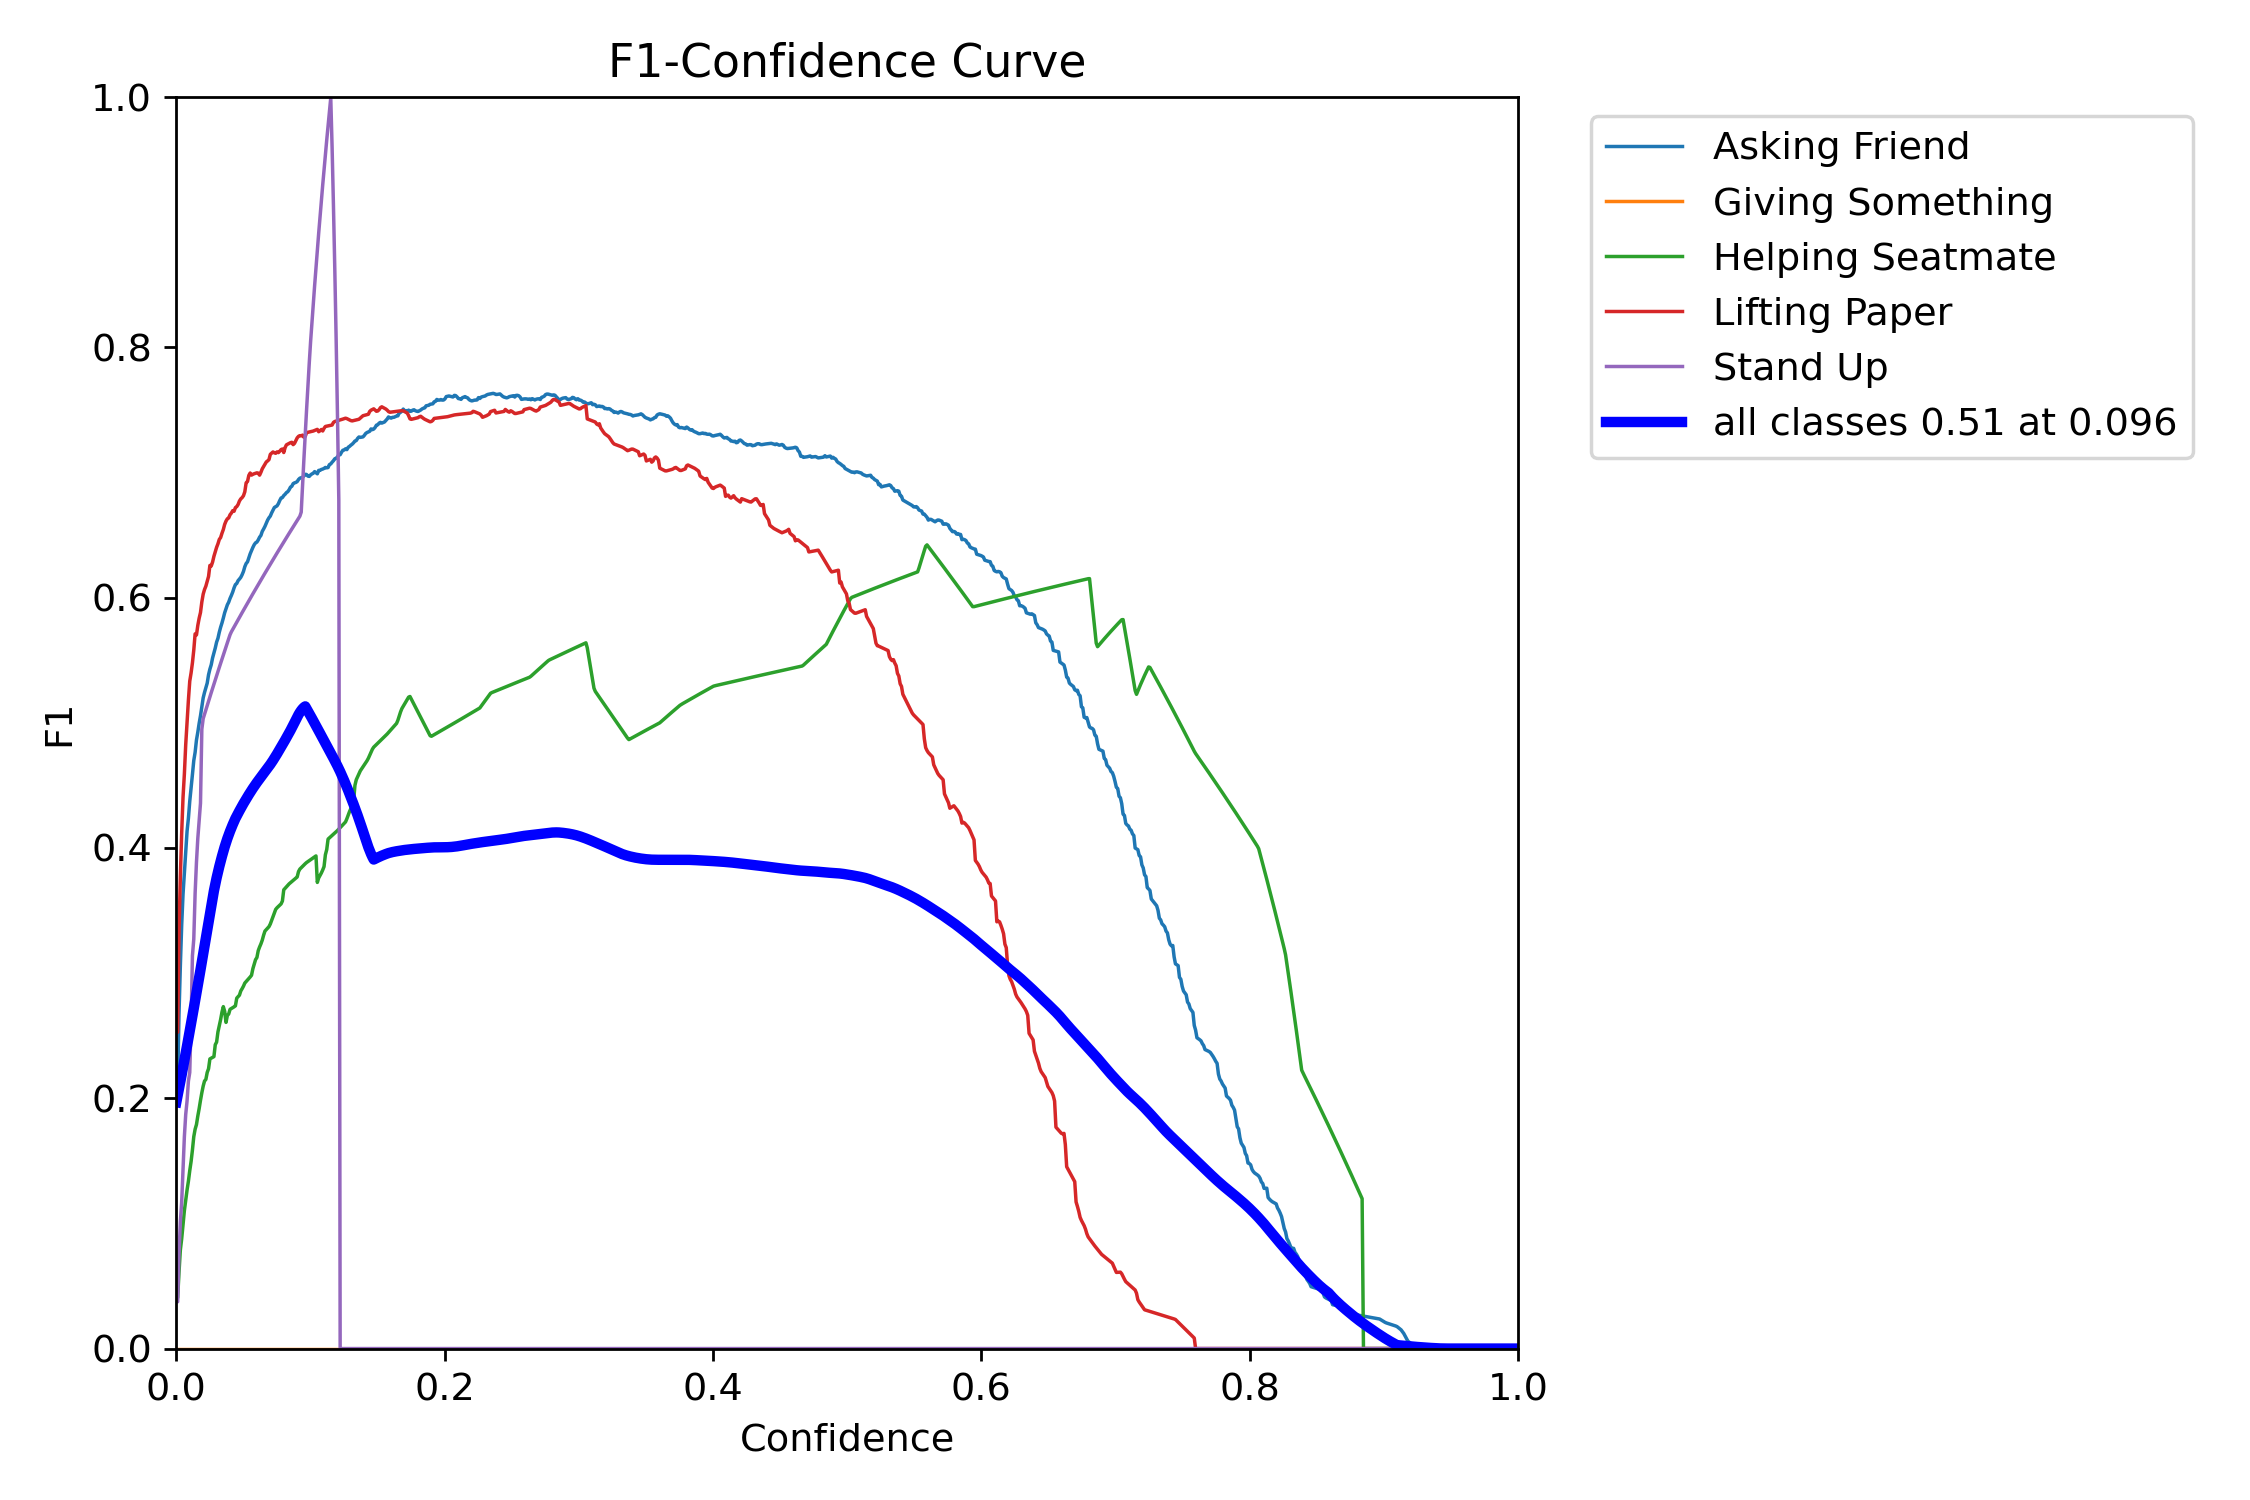

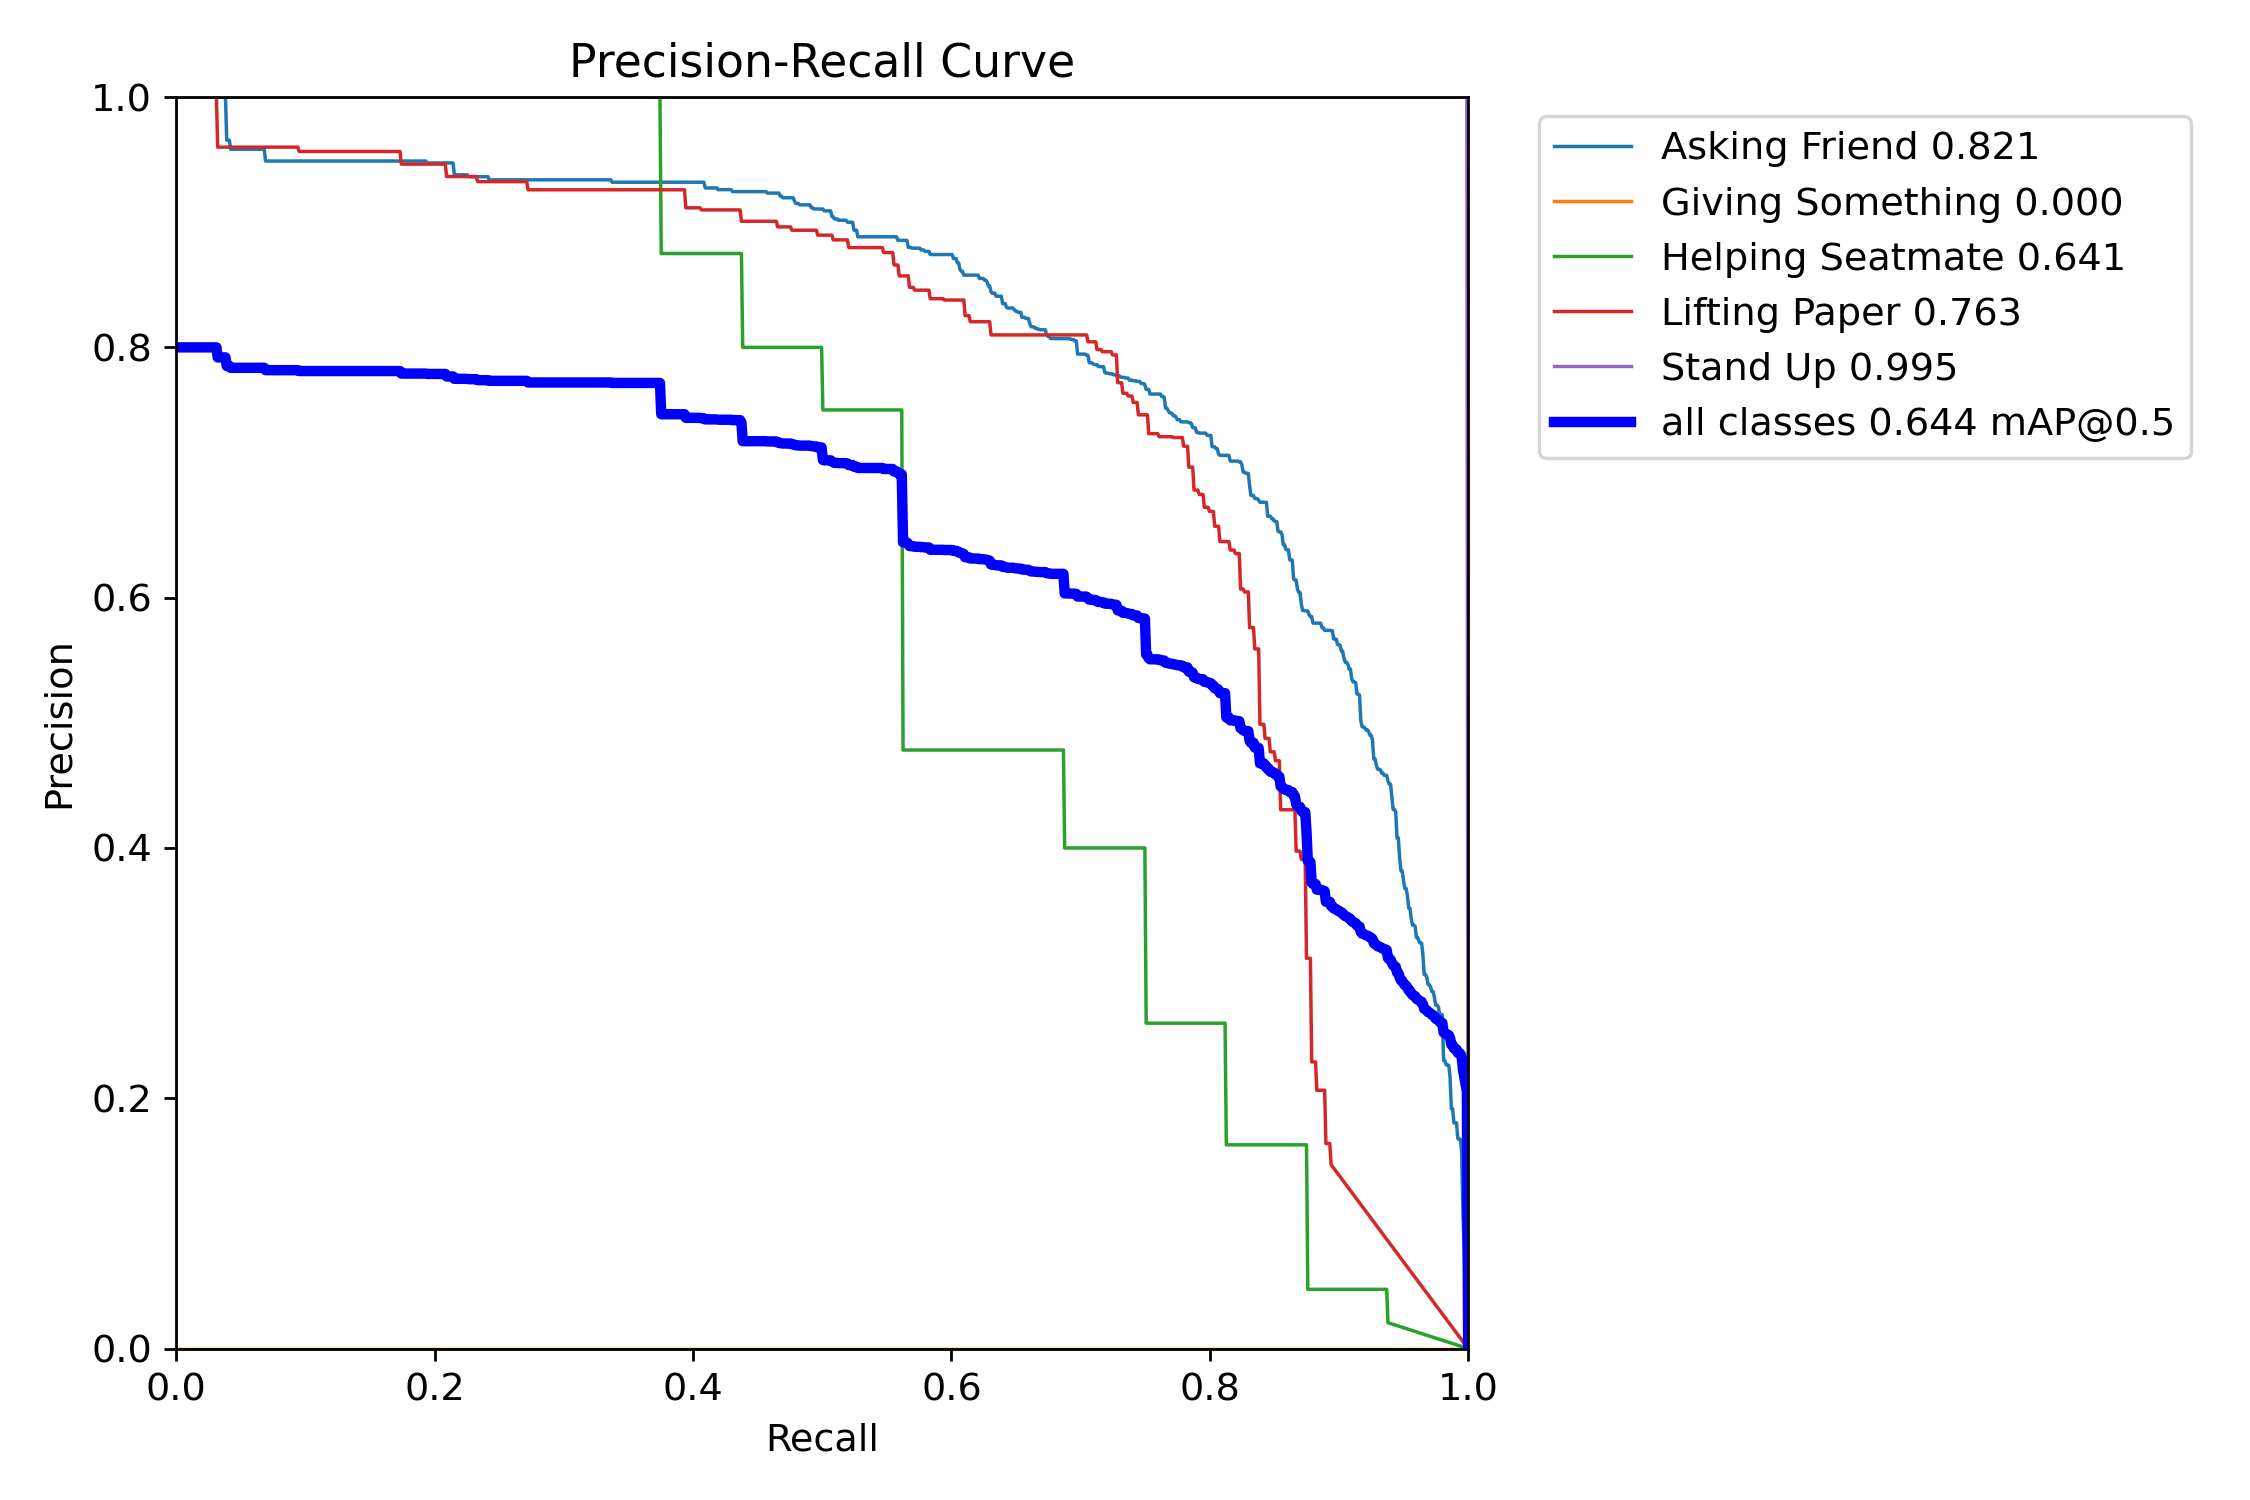

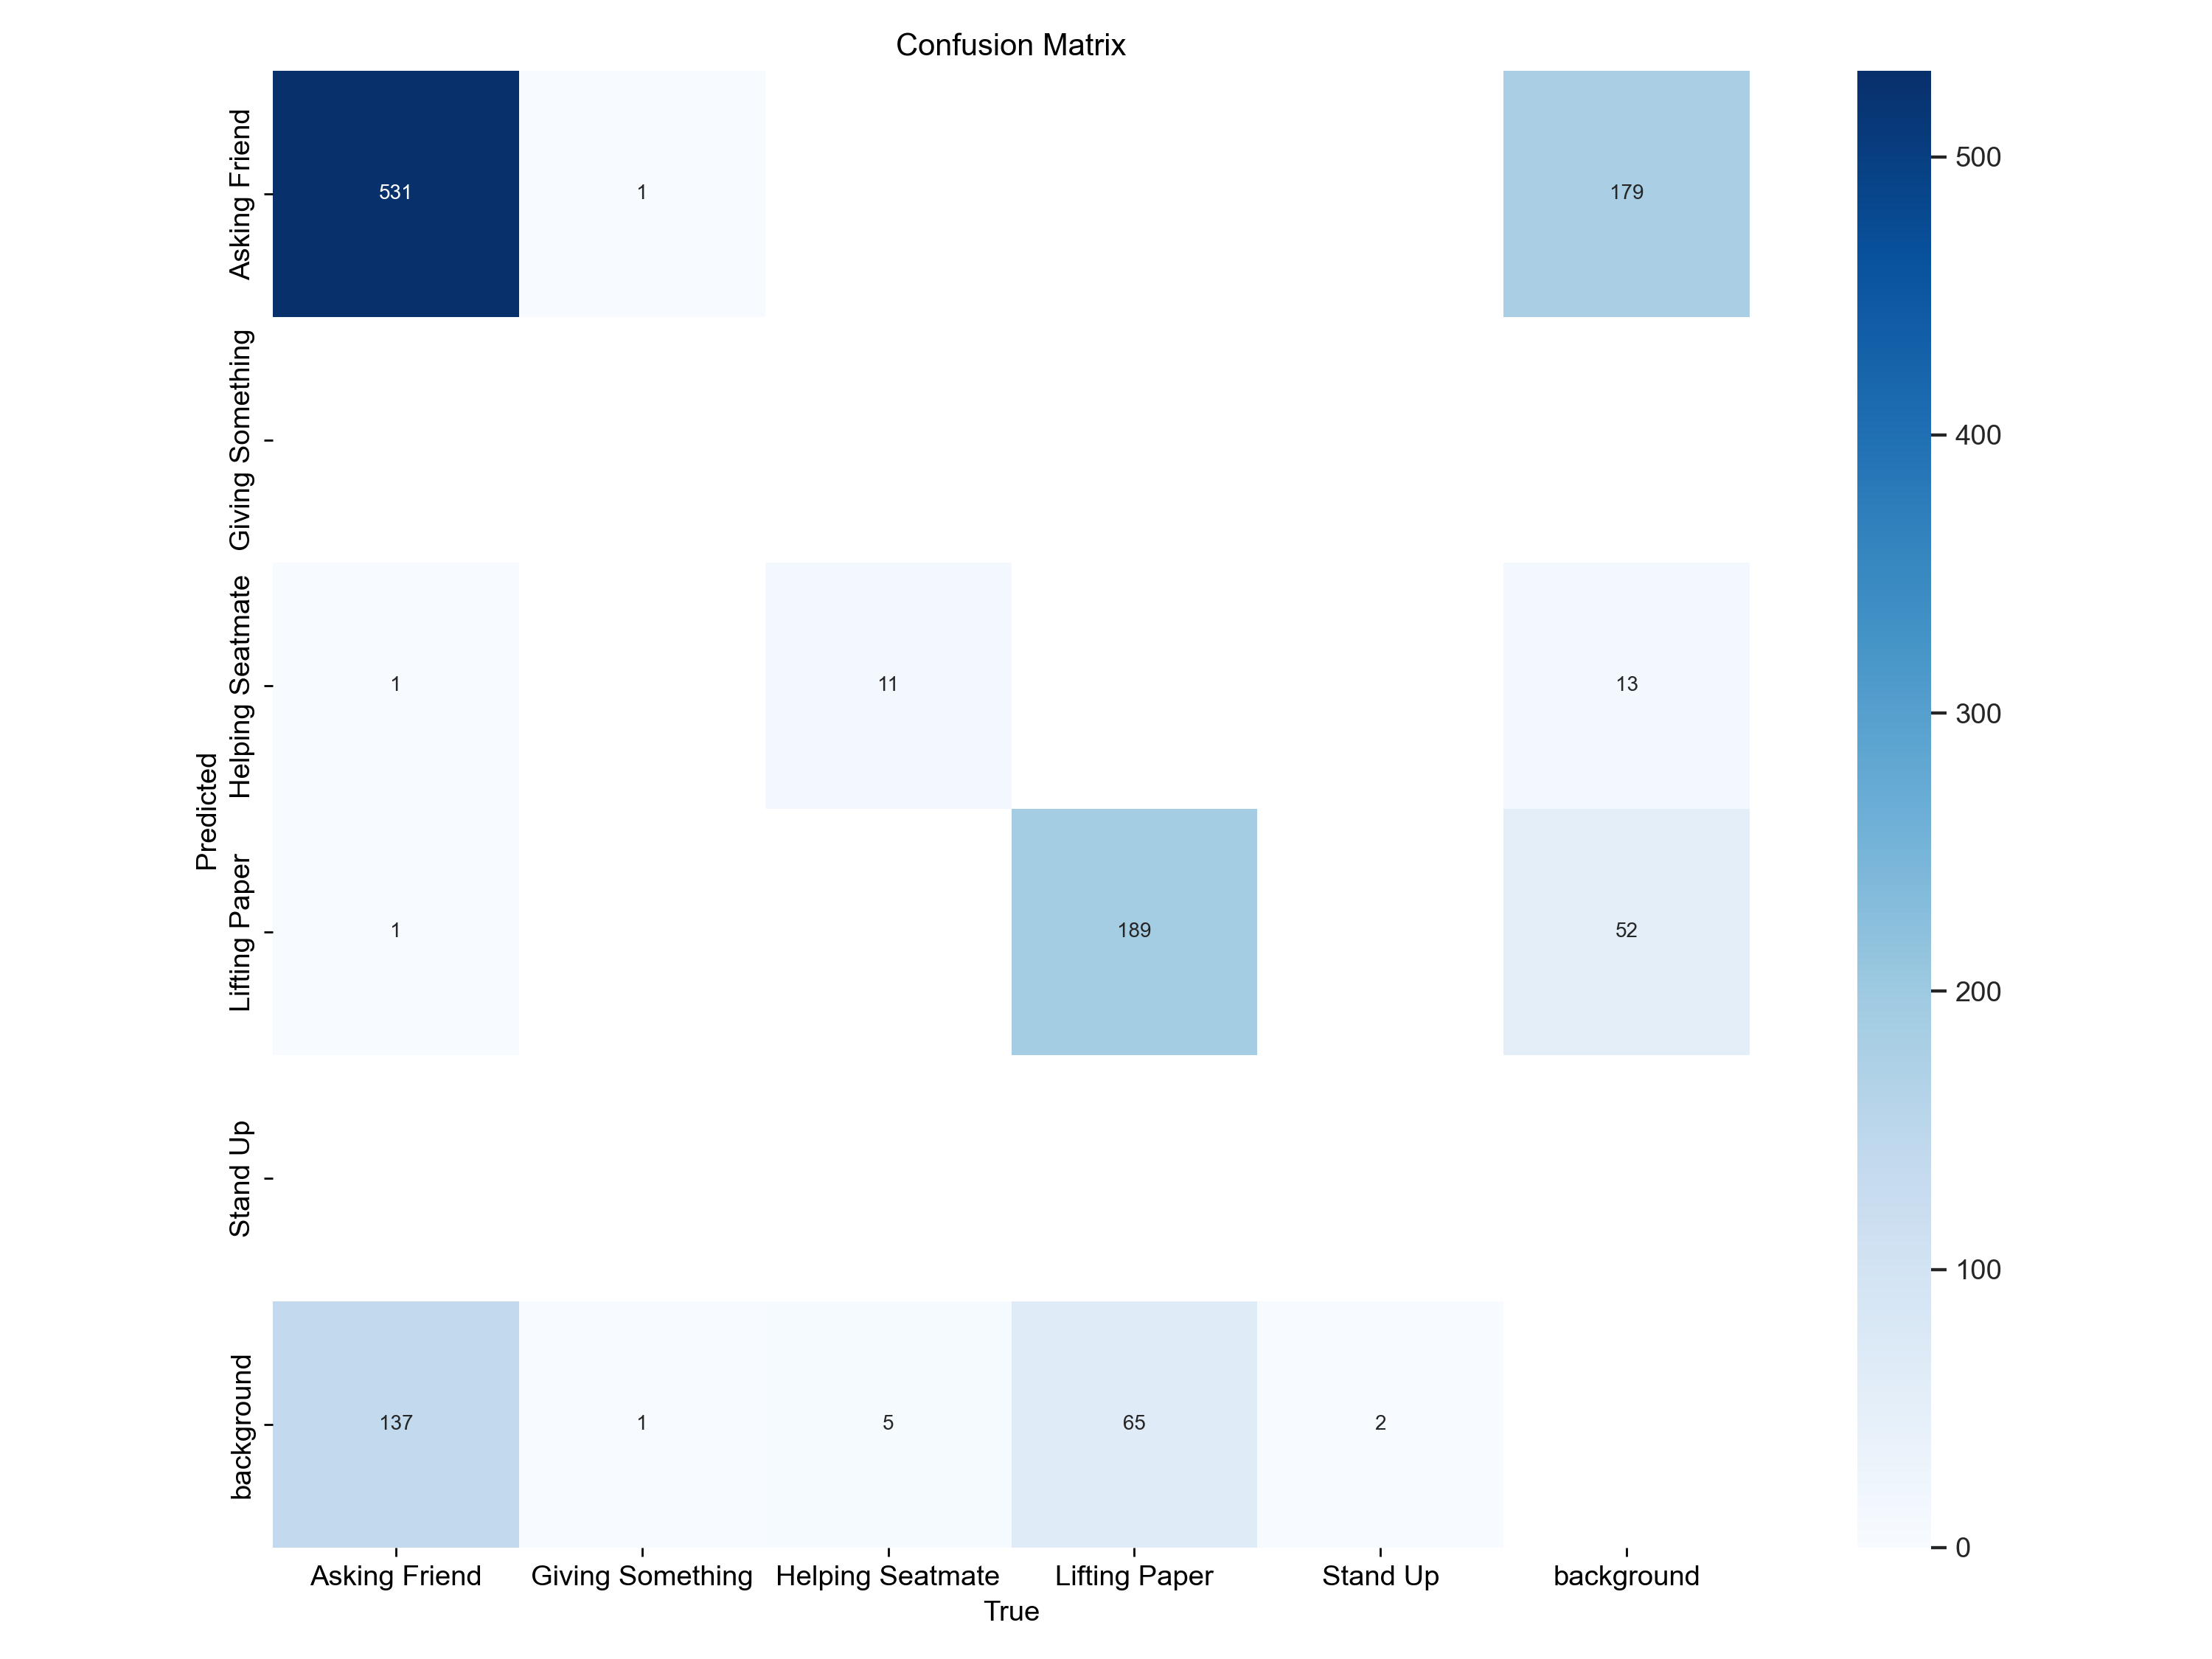

In [11]:
from IPython.display import Image
from IPython.display import display

x = Image(filename='runs/detect/train/F1_curve.png')
y = Image(filename='runs/detect/train/PR_curve.png')
z = Image(filename='runs/detect/train/confusion_matrix.png')
display(x, y,z)

# **YoloV5**

In [12]:
cd D:\projects\Feb26\exam cheating

D:\projects\Feb26\exam cheating


In [13]:
!mkdir v5

In [14]:
cd v5

D:\projects\Feb26\exam cheating\v5


In [15]:
model = YOLO("yolov5s6u.pt")  

# Use the model
results = model.train(
    data=Data_dir, 
    epochs=50, 
    imgsz=416, 
    batch=32)  

100%|██████████████████████████████████████████████████████████████████████████████| 29.6M/29.6M [00:00<00:00, 109MB/s]


New https://pypi.org/project/ultralytics/8.4.14 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.6  Python-3.10.9 torch-2.5.0+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: task=detect, mode=train, model=yolov5s6u.pt, data=D:/projects/Feb26/exam cheating/Dataset/data.yaml, epochs=50, time=None, patience=100, batch=32, imgsz=416, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, 

100%|█████████████████████████████████████████████████████████████████████████████| 5.35M/5.35M [00:00<00:00, 98.4MB/s]


AMP: checks passed 
WARNING  imgsz=[416] must be multiple of max stride 64, updating to [448]


train: Scanning D:\projects\Feb26\exam cheating\Dataset\train\labels.cache... 6312 images, 39 backgrounds, 0 corrupt: 1
val: Scanning D:\projects\Feb26\exam cheating\Dataset\valid\labels.cache... 259 images, 1 backgrounds, 0 corrupt: 100%|


...

      50/50      4.24G     0.7822     0.5041     0.8837         25        448: 100%|██████████| 198/198 [01:01<00:00,  
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<0

                   all        259        944      0.858      0.571      0.651      0.384



50 epochs completed in 0.928 hours.
Optimizer stripped from runs\detect\train\weights\last.pt, 27.3MB
Optimizer stripped from runs\detect\train\weights\best.pt, 27.3MB

Validating runs\detect\train\weights\best.pt...
Ultralytics 8.3.6  Python-3.10.9 torch-2.5.0+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
YOLOv5s6u summary (fused): 277 layers, 13,437,892 parameters, 0 gradients, 19.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:03<0


                   all        259        944      0.848      0.612      0.663      0.421
         Asking Friend        238        670      0.879      0.733       0.87      0.583
      Giving Something          2          2          1          0    0.00458    0.00275
      Helping Seatmate         16         16      0.603      0.625      0.617      0.456
         Lifting Paper        191        254      0.869      0.703      0.829      0.441
              Stand Up          2          2      0.891          1      0.995      0.622
Speed: 0.1ms preprocess, 2.2ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to runs\detect\train


In [16]:
p_yolo5 = 0.848
r_yolo5 = 0.612
mAP_yolo5 = 0.663

storeResults('Yolo v5',p_yolo5,r_yolo5,mAP_yolo5)

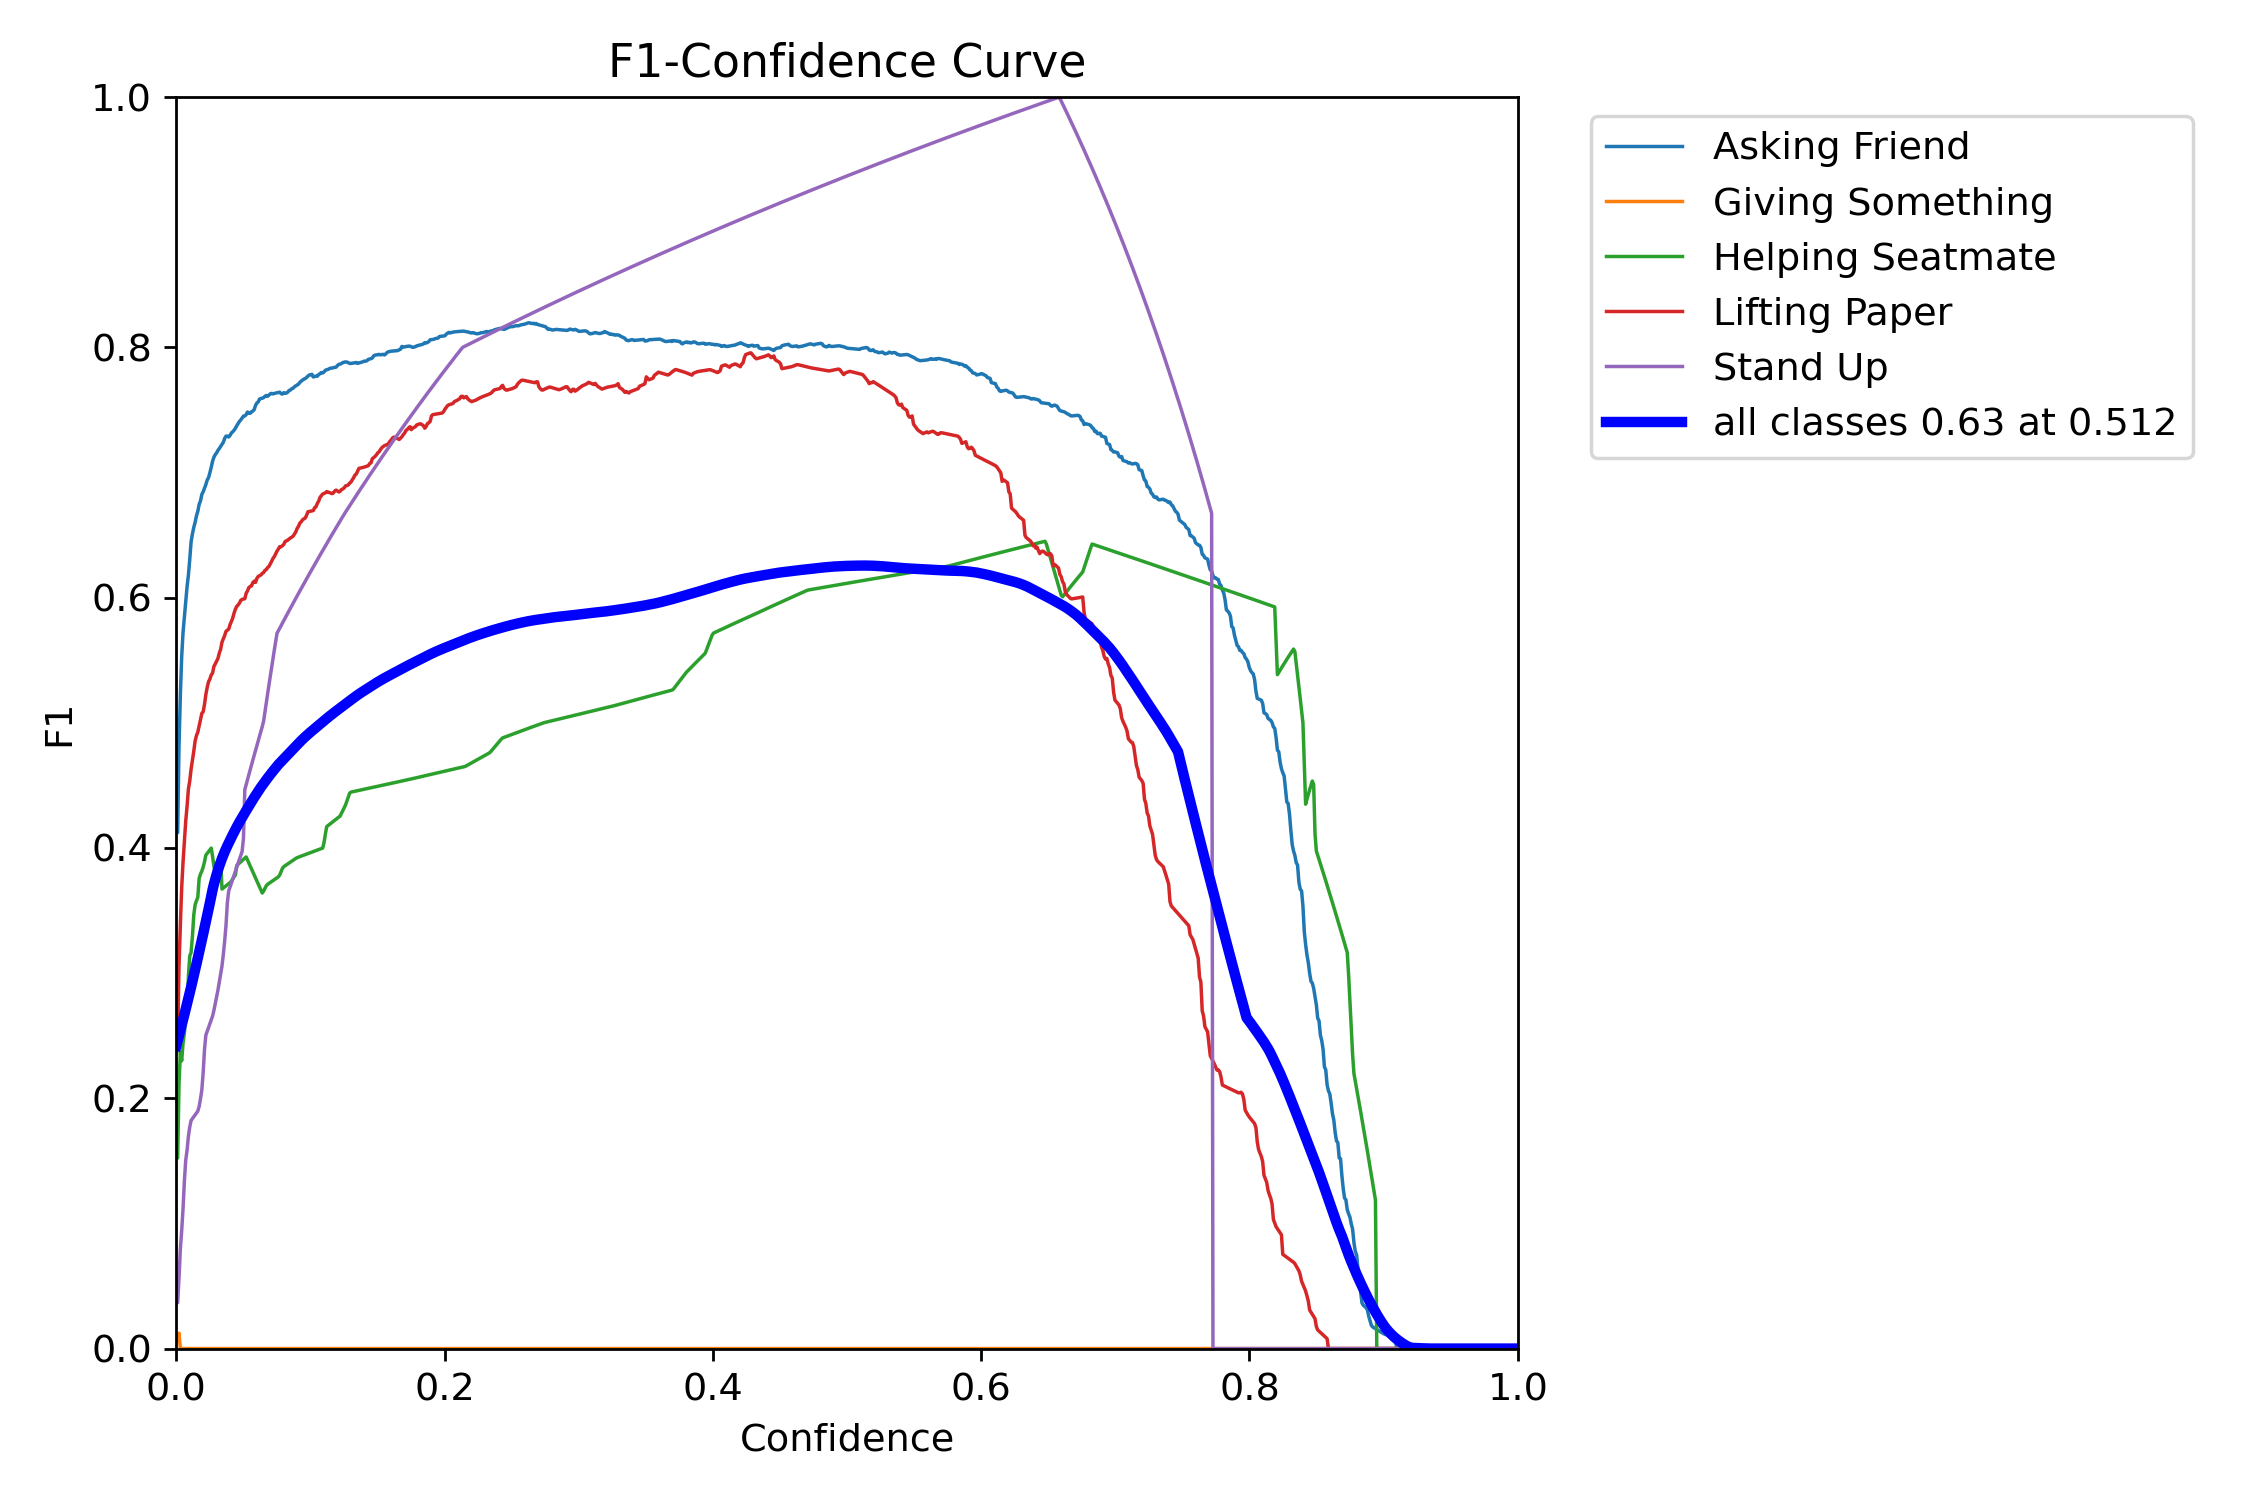

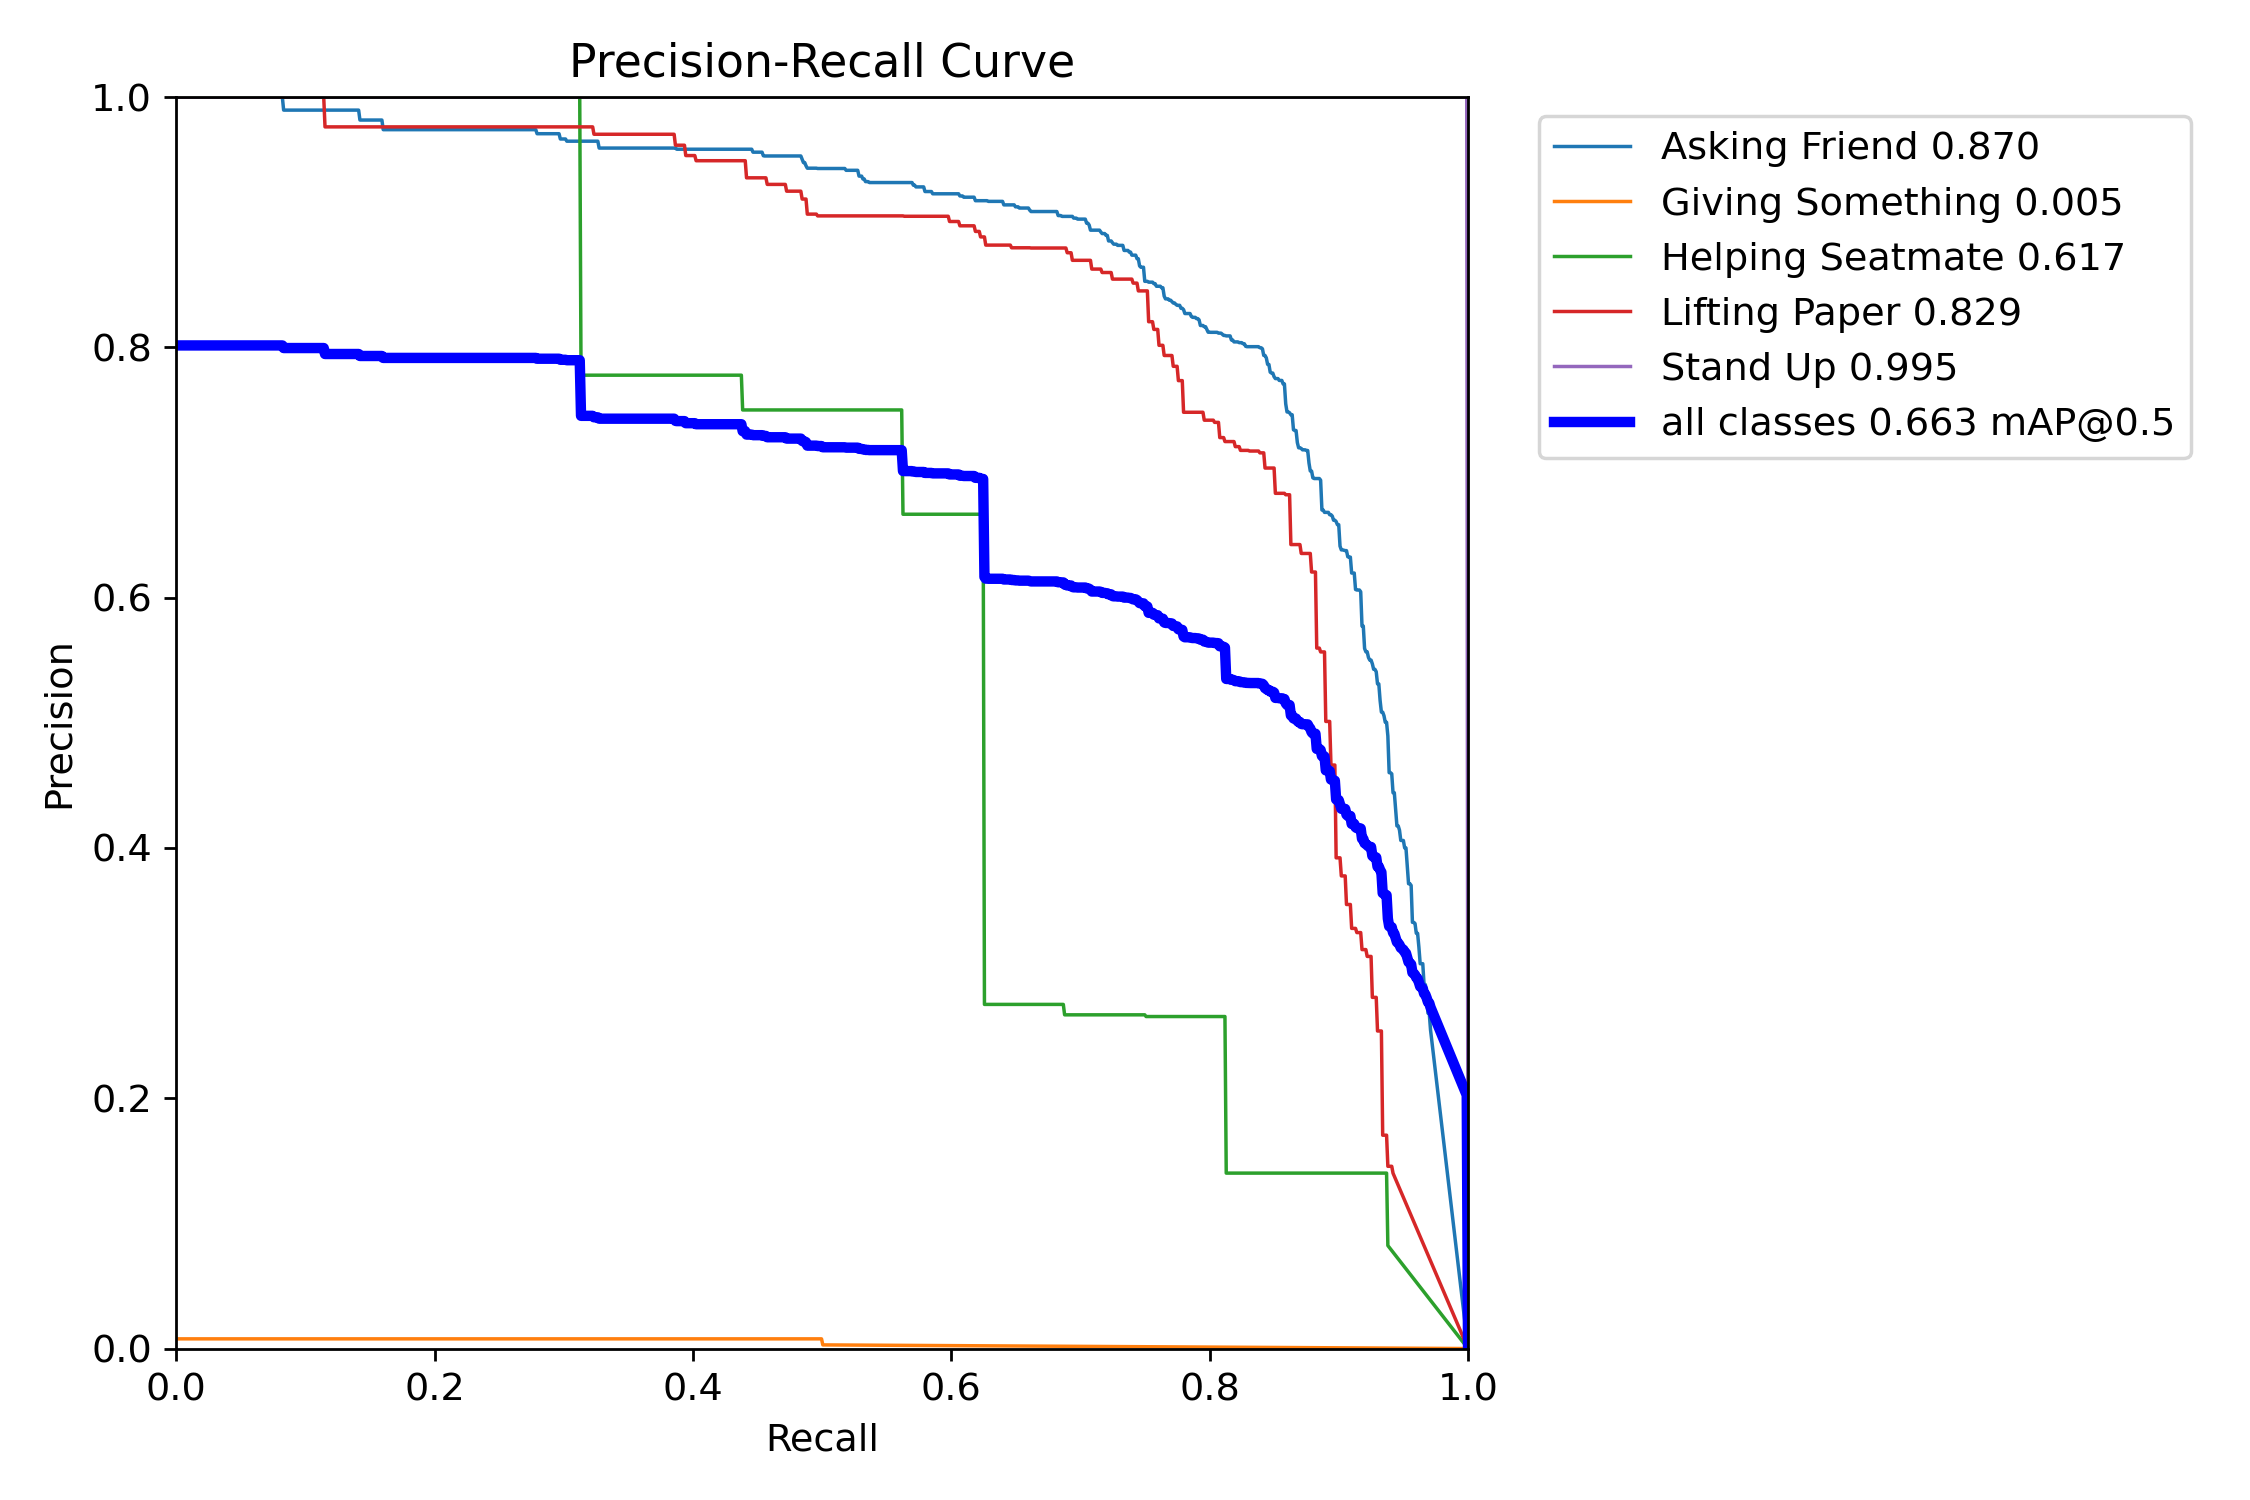

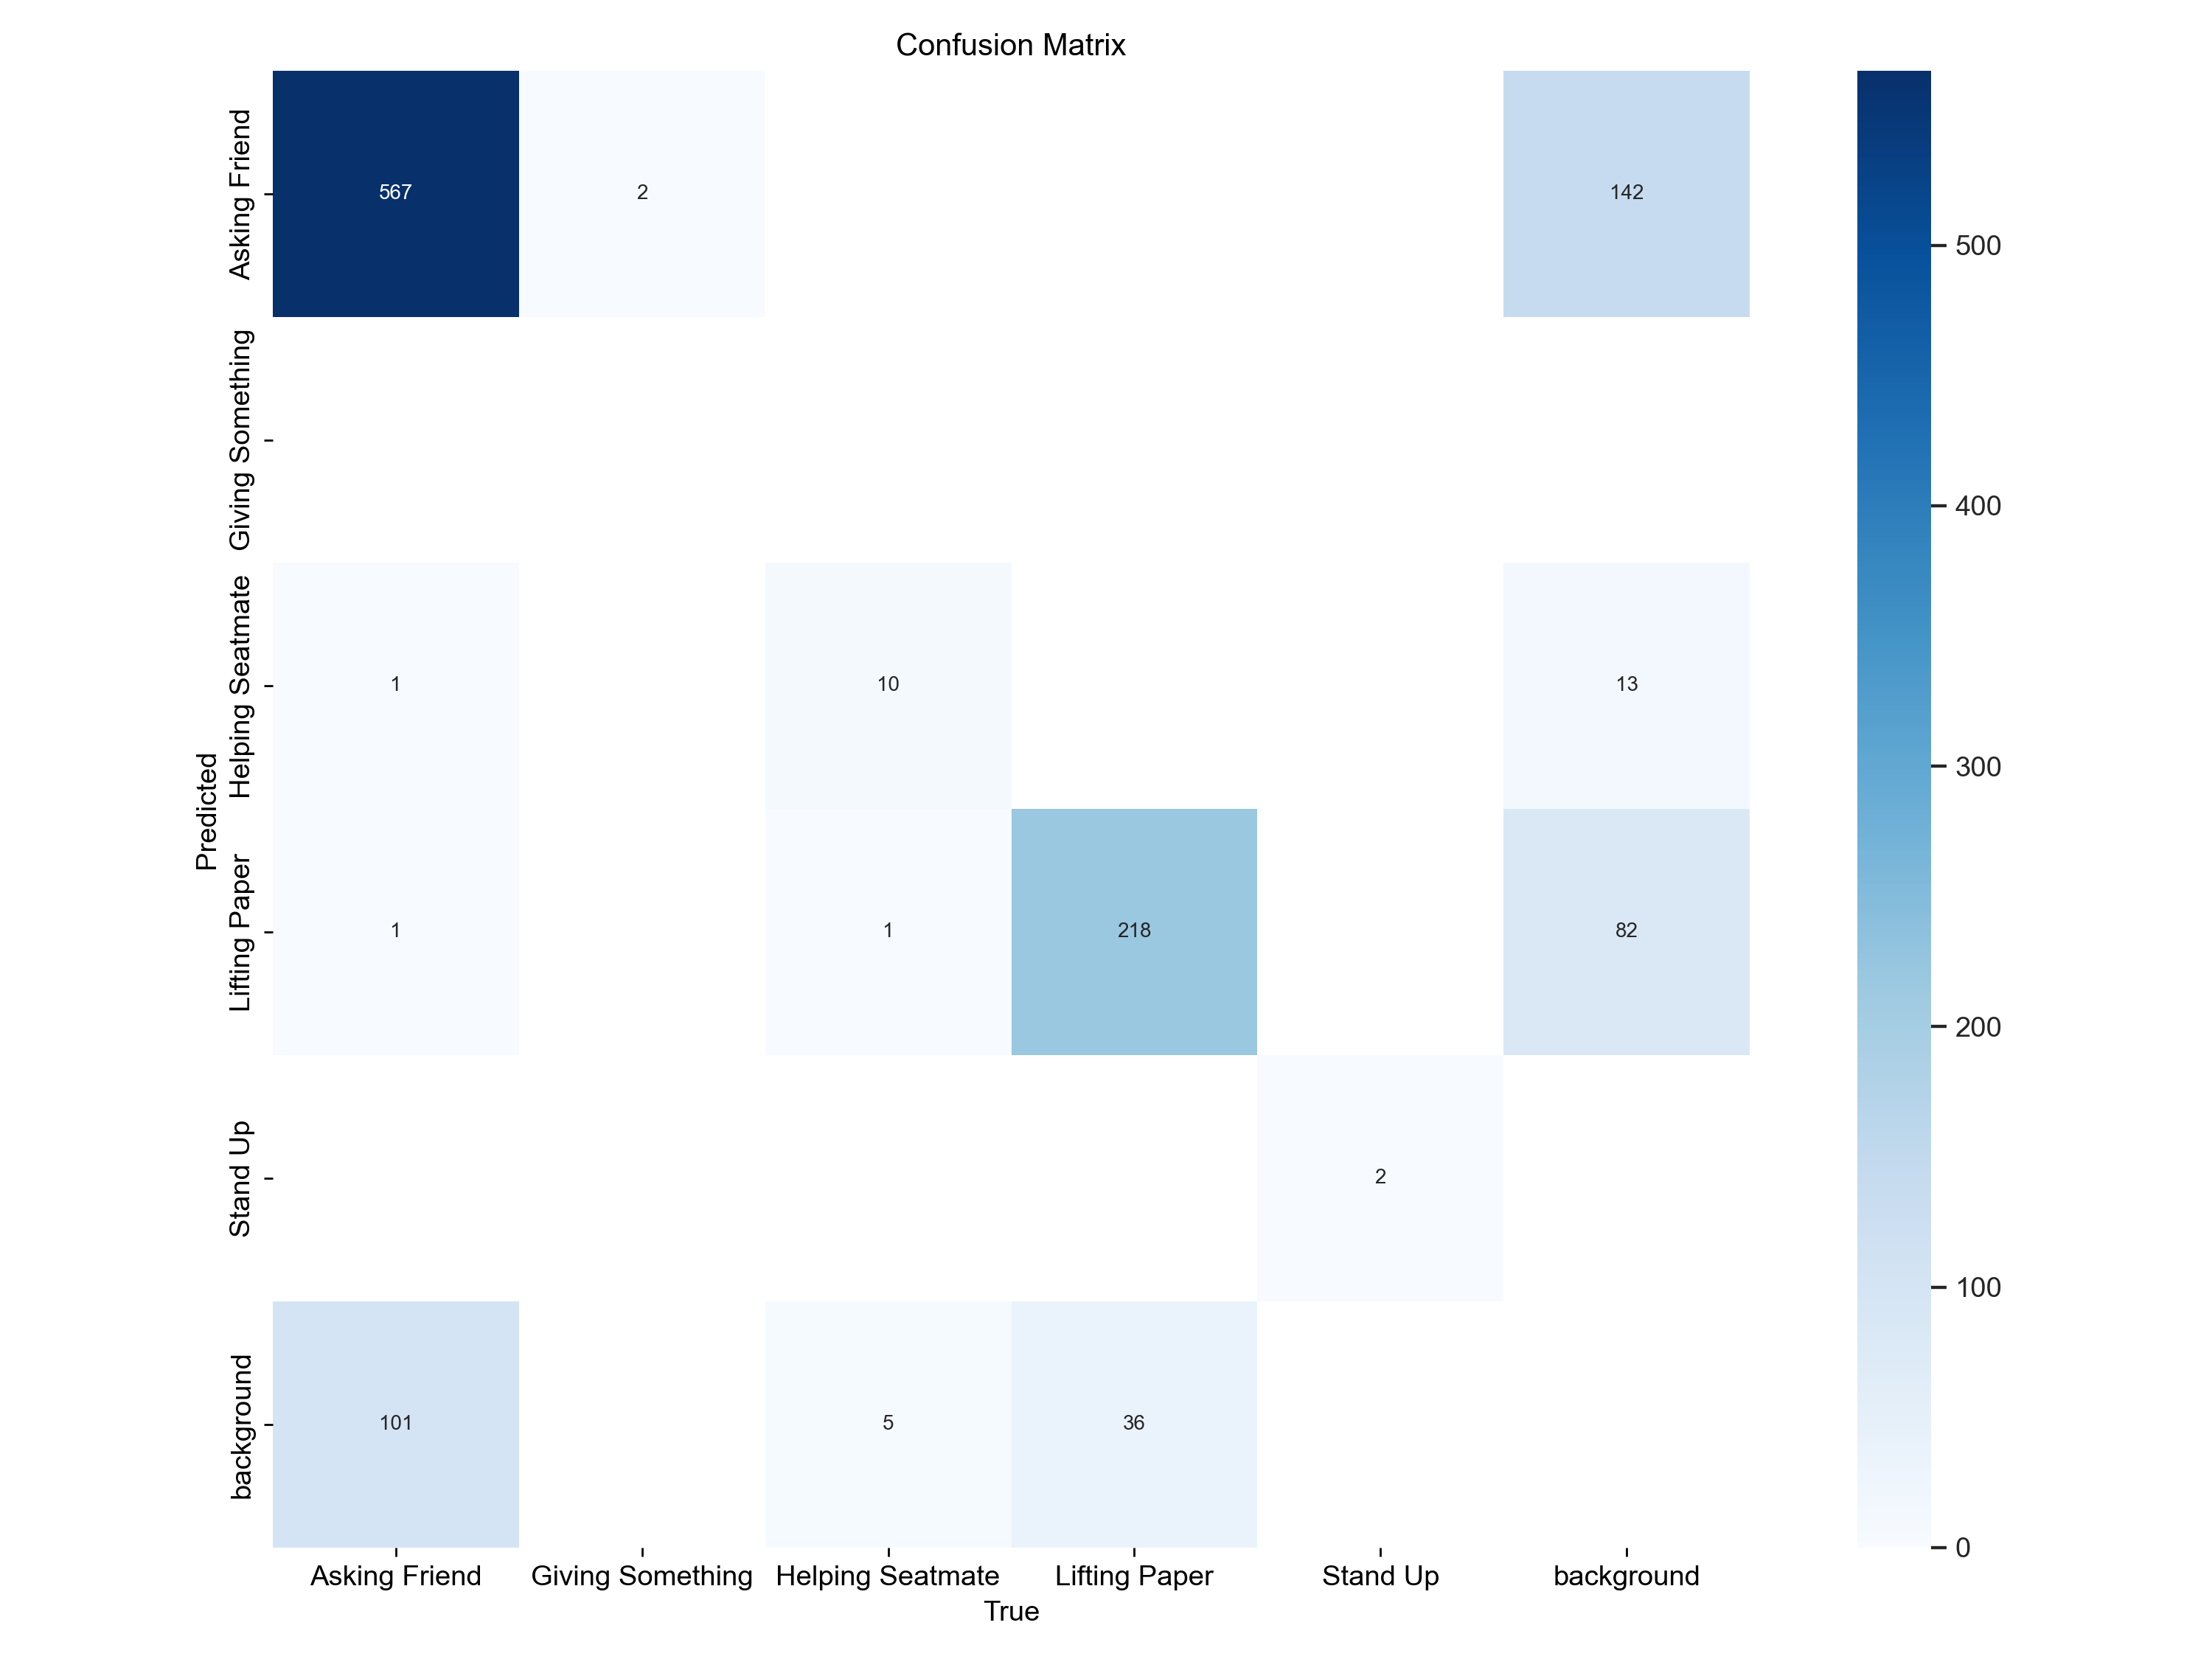

In [17]:
x = Image(filename='runs/detect/train/F1_curve.png')
y = Image(filename='runs/detect/train/PR_curve.png')
z = Image(filename='runs/detect/train/confusion_matrix.png')
display(x, y,z)

## Yolov9

In [18]:
cd D:\projects\Feb26\exam cheating

D:\projects\Feb26\exam cheating


In [19]:
!mkdir v9

In [20]:
cd v9

D:\projects\Feb26\exam cheating\v9


In [21]:
model = YOLO("yolov9t.pt") 

results = model.train(
    data=Data_dir, 
    epochs=50, 
    imgsz=416, 
    batch=32)   

100%|█████████████████████████████████████████████████████████████████████████████| 4.74M/4.74M [00:00<00:00, 97.2MB/s]

New https://pypi.org/project/ultralytics/8.4.14 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.6  Python-3.10.9 torch-2.5.0+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: task=detect, mode=train, model=yolov9t.pt, data=D:/projects/Feb26/exam cheating/Dataset/data.yaml, epochs=50, time=None, patience=100, batch=32, imgsz=416, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, em

Overriding model.yaml nc=80 with nc=5

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7872  ultralytics.nn.modules.block.ELAN1           [32, 32, 32, 16]              
  3                  -1  1     18560  ultralytics.nn.modules.block.AConv           [32, 64]                      
  4                  -1  1     65216  ultralytics.nn.modules.block.RepNCSPELAN4    [64, 64, 64, 32, 3]           
  5                  -1  1     55488  ultralytics.nn.modules.block.AConv           [64, 96]                      
  6                  -1  1    145824  ultralytics.nn.modules.block.RepNCSPELAN4    [96, 96, 96, 48, 3]           
  7                  -1  1    110848  ultralytics

100%|█████████████████████████████████████████████████████████████████████████████| 5.35M/5.35M [00:00<00:00, 15.4MB/s]


AMP: checks passed 


...

      50/50      2.52G     0.8732     0.5784     0.9446         25        416: 100%|██████████| 198/198 [01:43<00:00,  
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<0

                   all        259        944      0.809      0.597      0.647      0.384



50 epochs completed in 1.545 hours.
Optimizer stripped from runs\detect\train\weights\last.pt, 4.1MB
Optimizer stripped from runs\detect\train\weights\best.pt, 4.1MB

Validating runs\detect\train\weights\best.pt...
Ultralytics 8.3.6  Python-3.10.9 torch-2.5.0+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
YOLOv9t summary (fused): 504 layers, 1,730,799 parameters, 0 gradients, 6.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:03<0


                   all        259        944      0.828      0.598      0.659      0.398
         Asking Friend        238        670      0.852      0.707      0.862      0.573
      Giving Something          2          2          1          0          0          0
      Helping Seatmate         16         16      0.668      0.628      0.687       0.49
         Lifting Paper        191        254      0.817      0.654      0.751      0.329
              Stand Up          2          2      0.804          1      0.995      0.597
Speed: 0.5ms preprocess, 3.6ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs\detect\train


In [22]:
p_yolo9 = 0.828
r_yolo9 = 0.598
mAP_yolo9 = 0.659

storeResults('Yolo v9',p_yolo9,r_yolo9,mAP_yolo9)

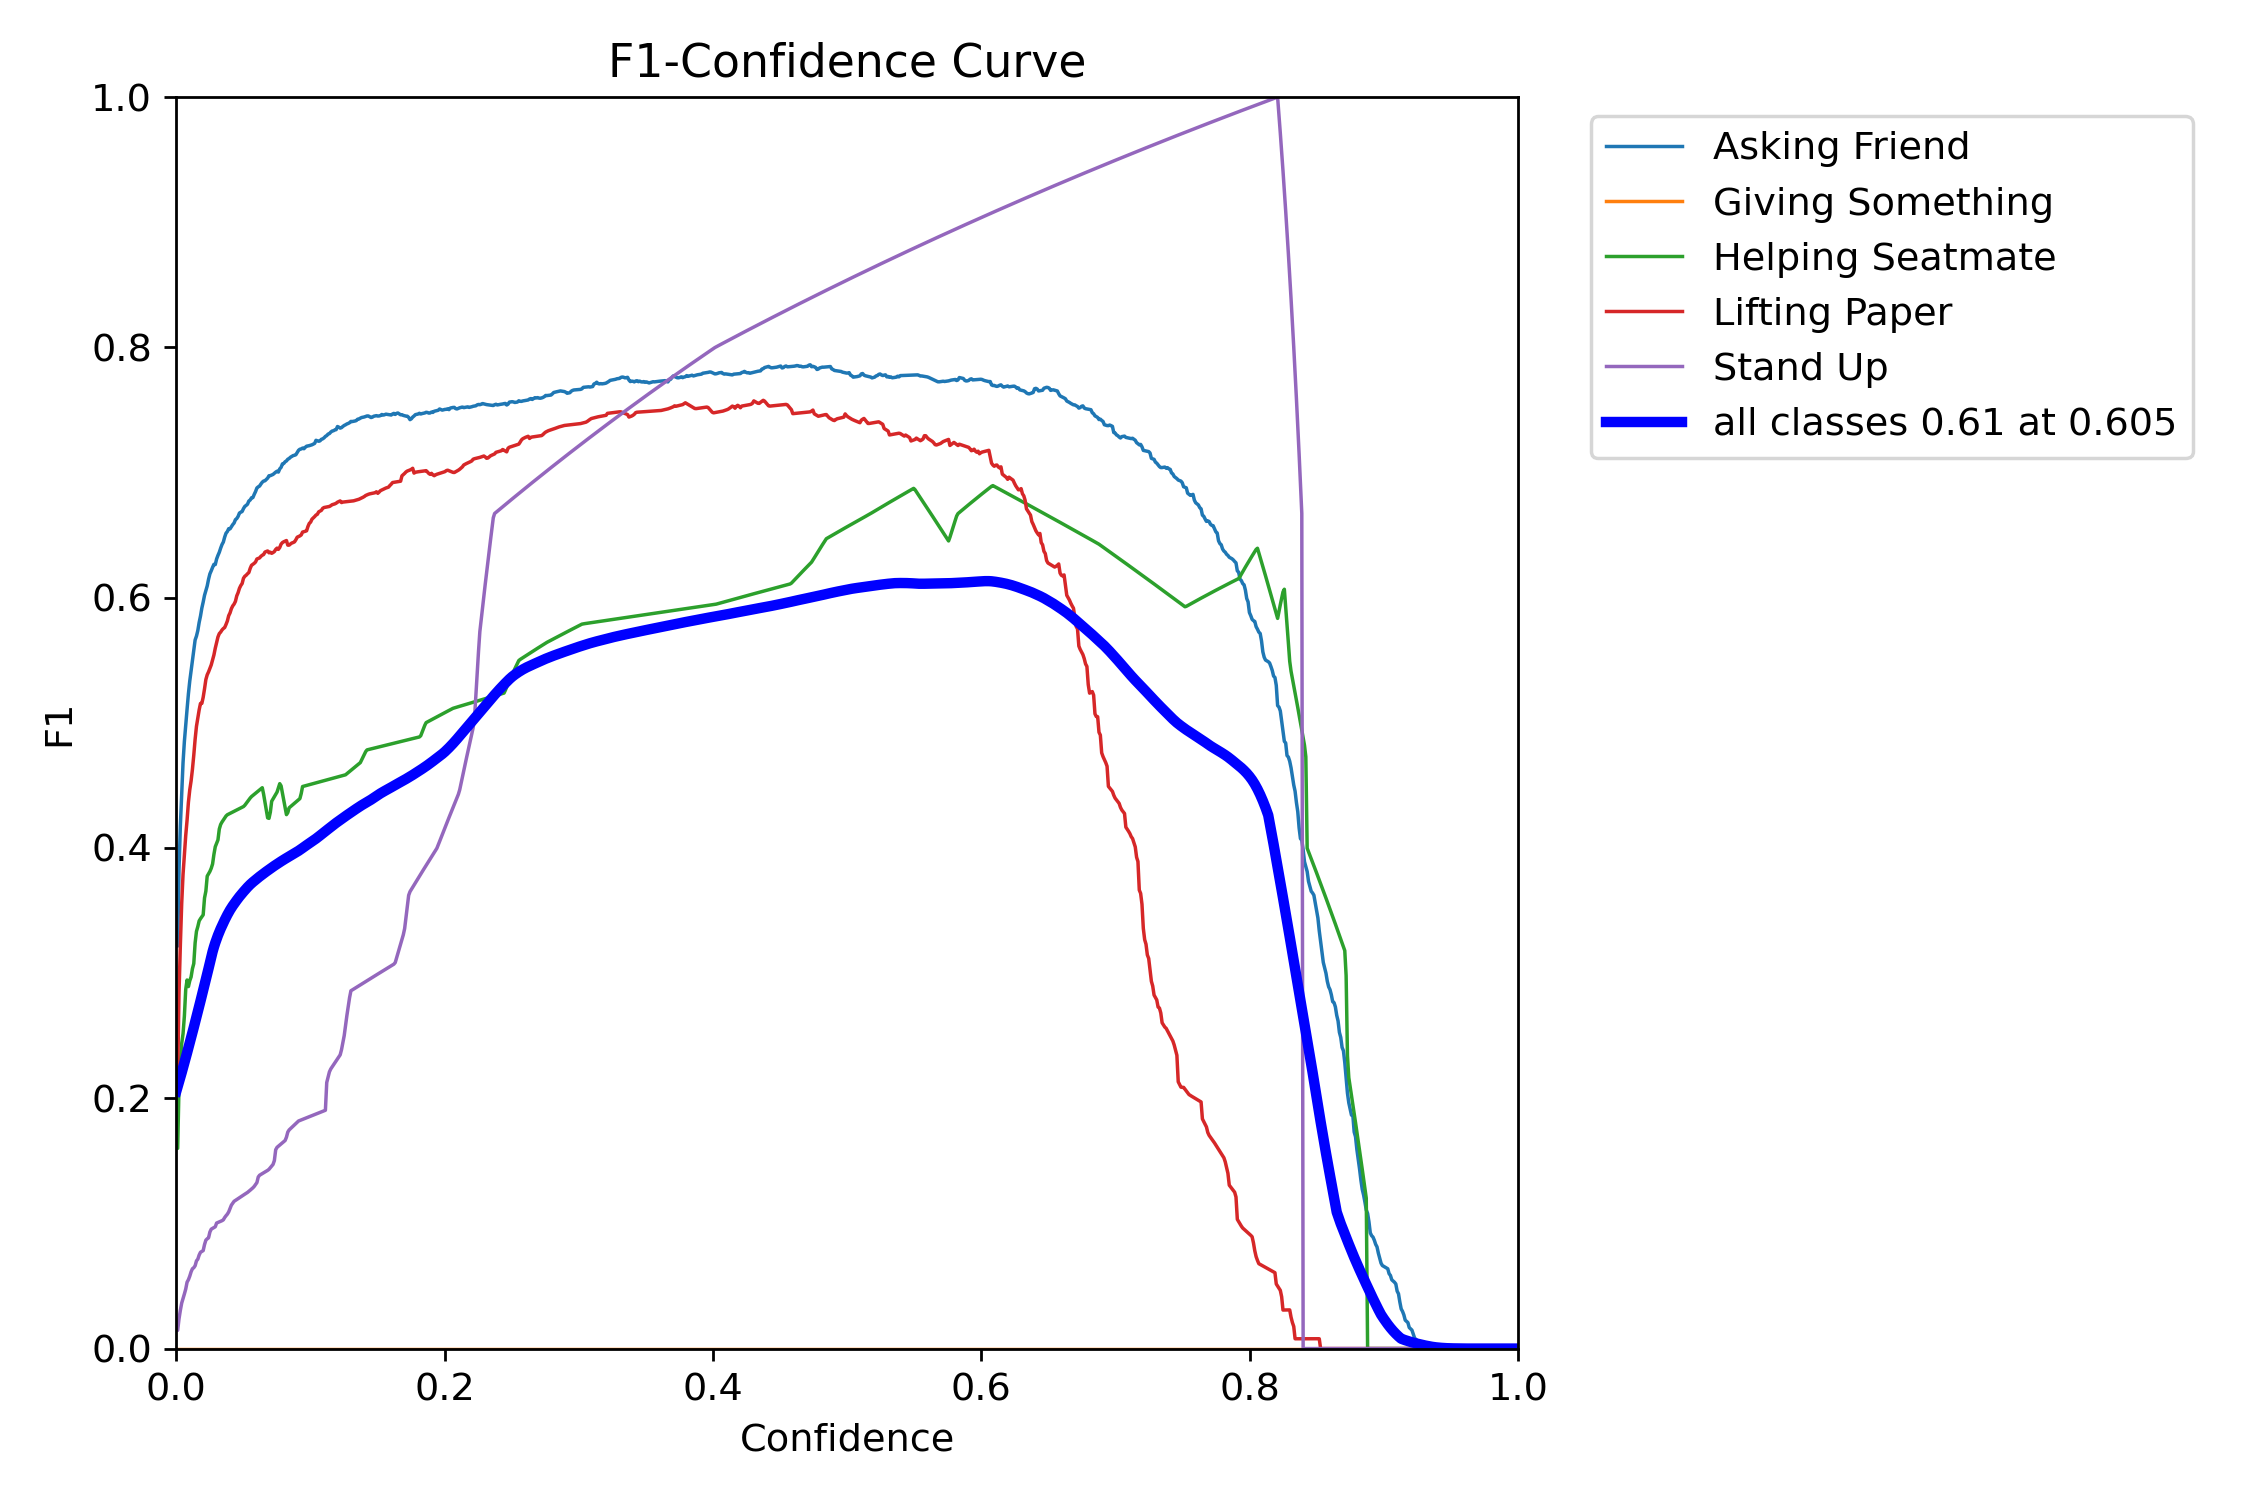

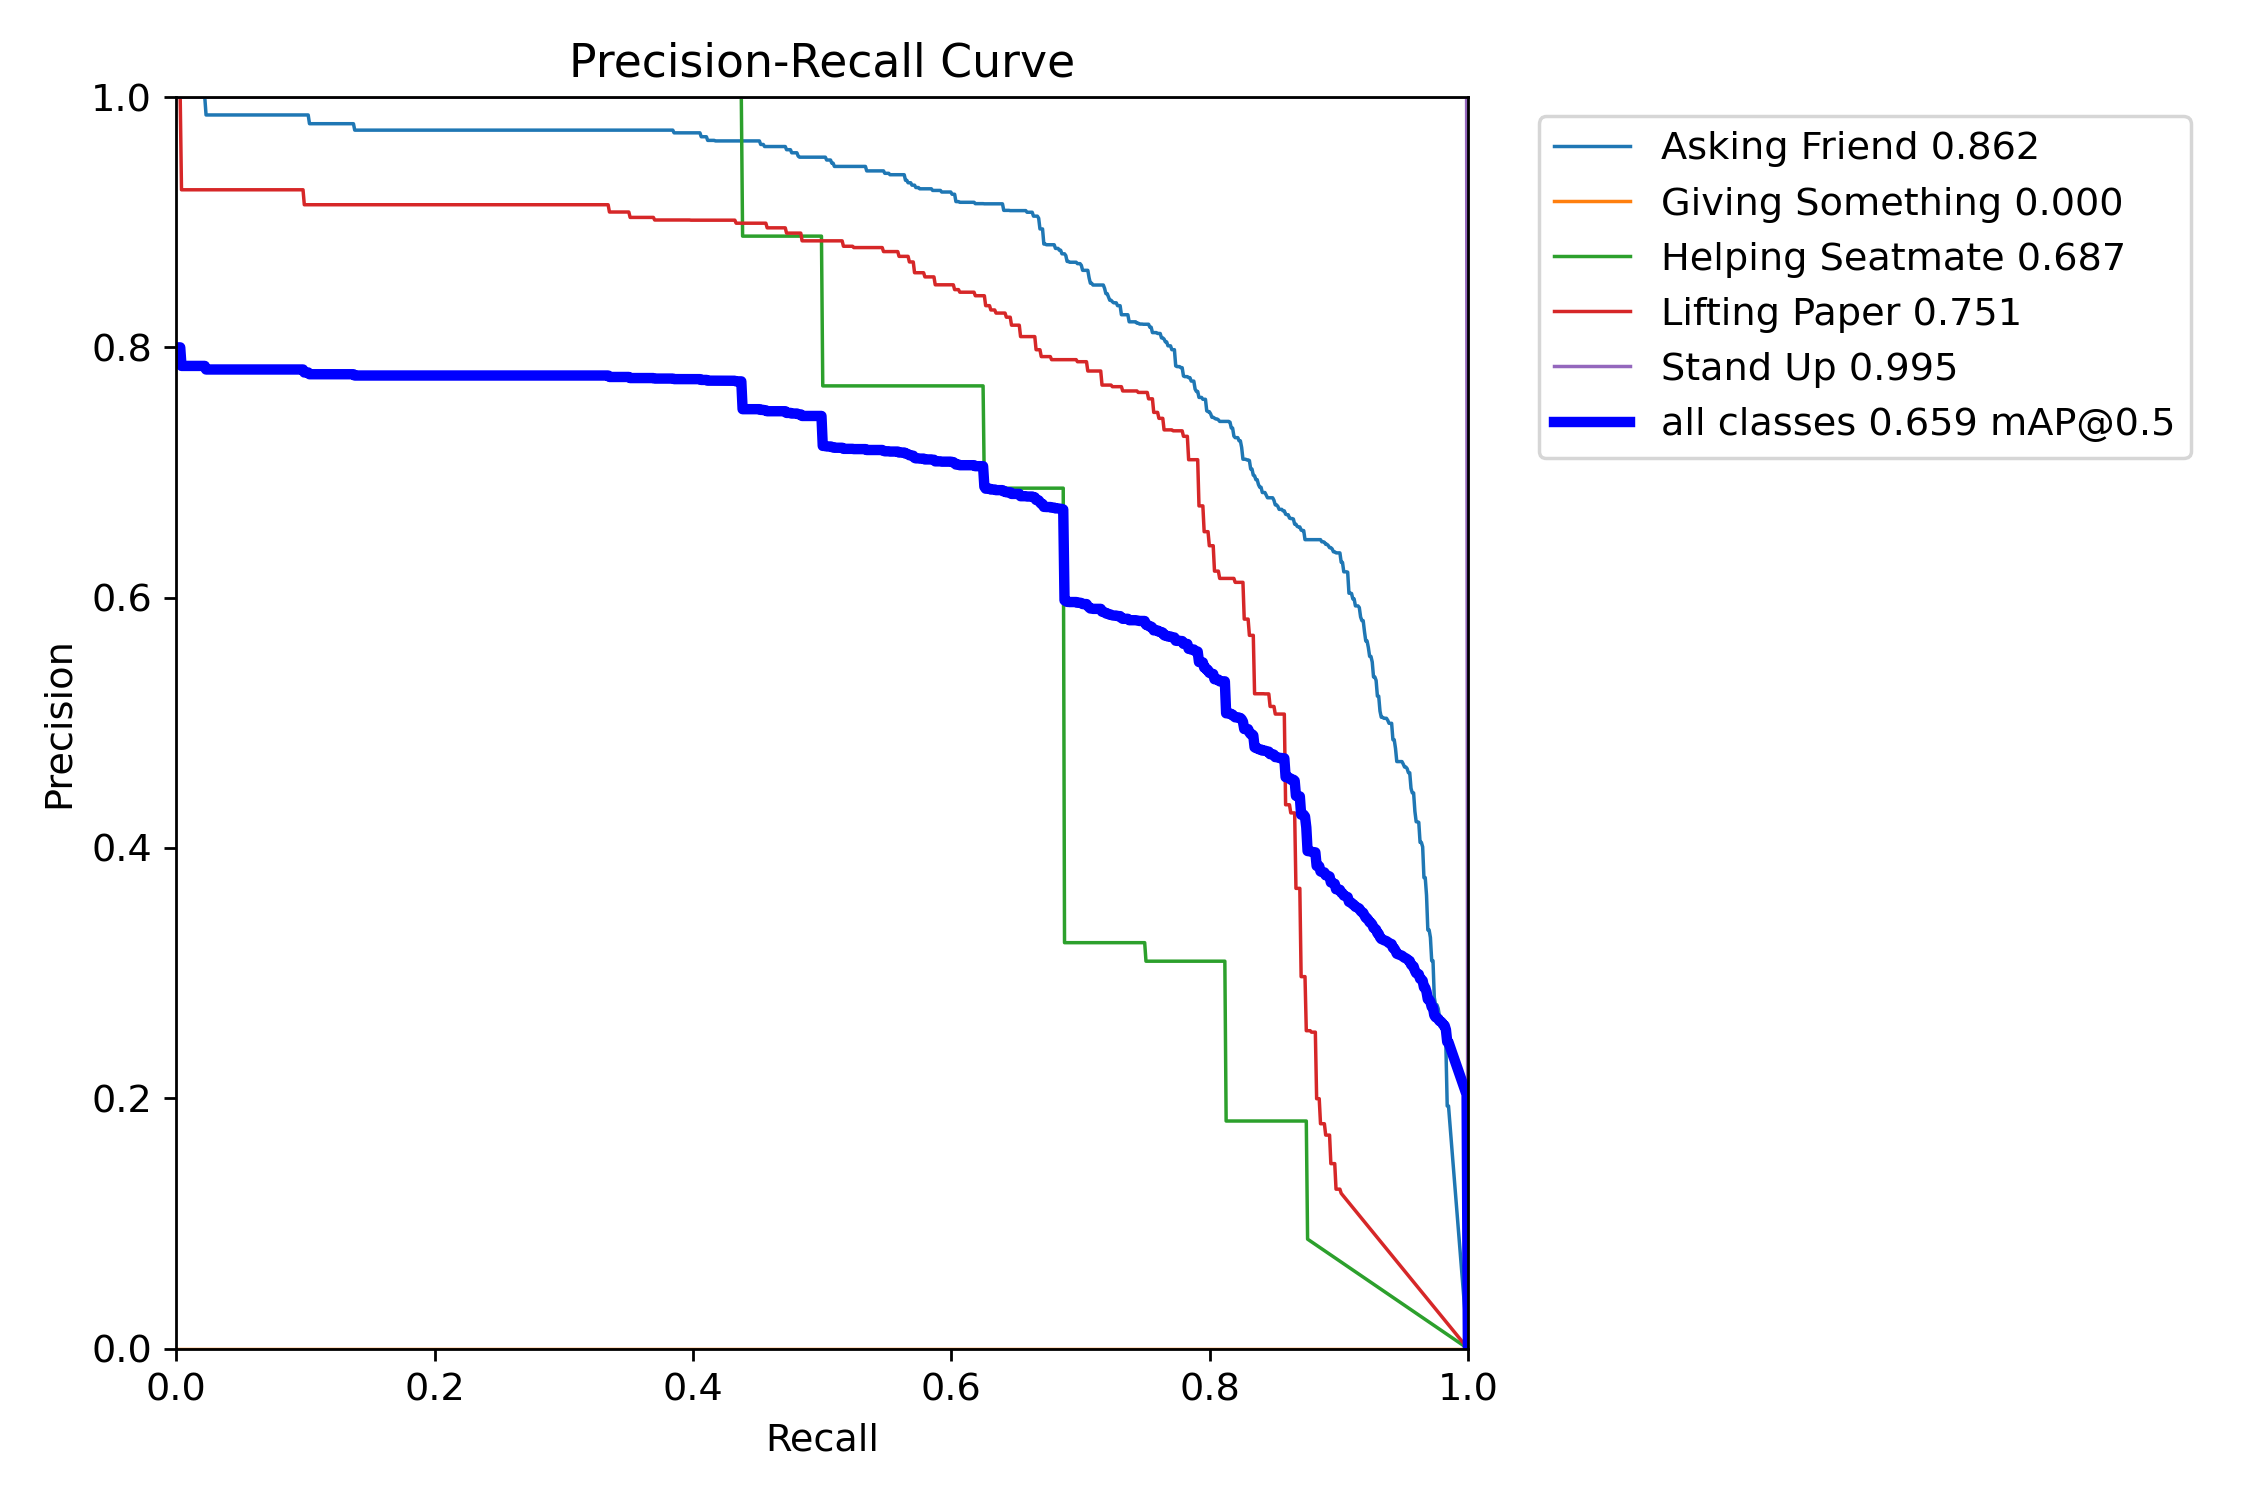

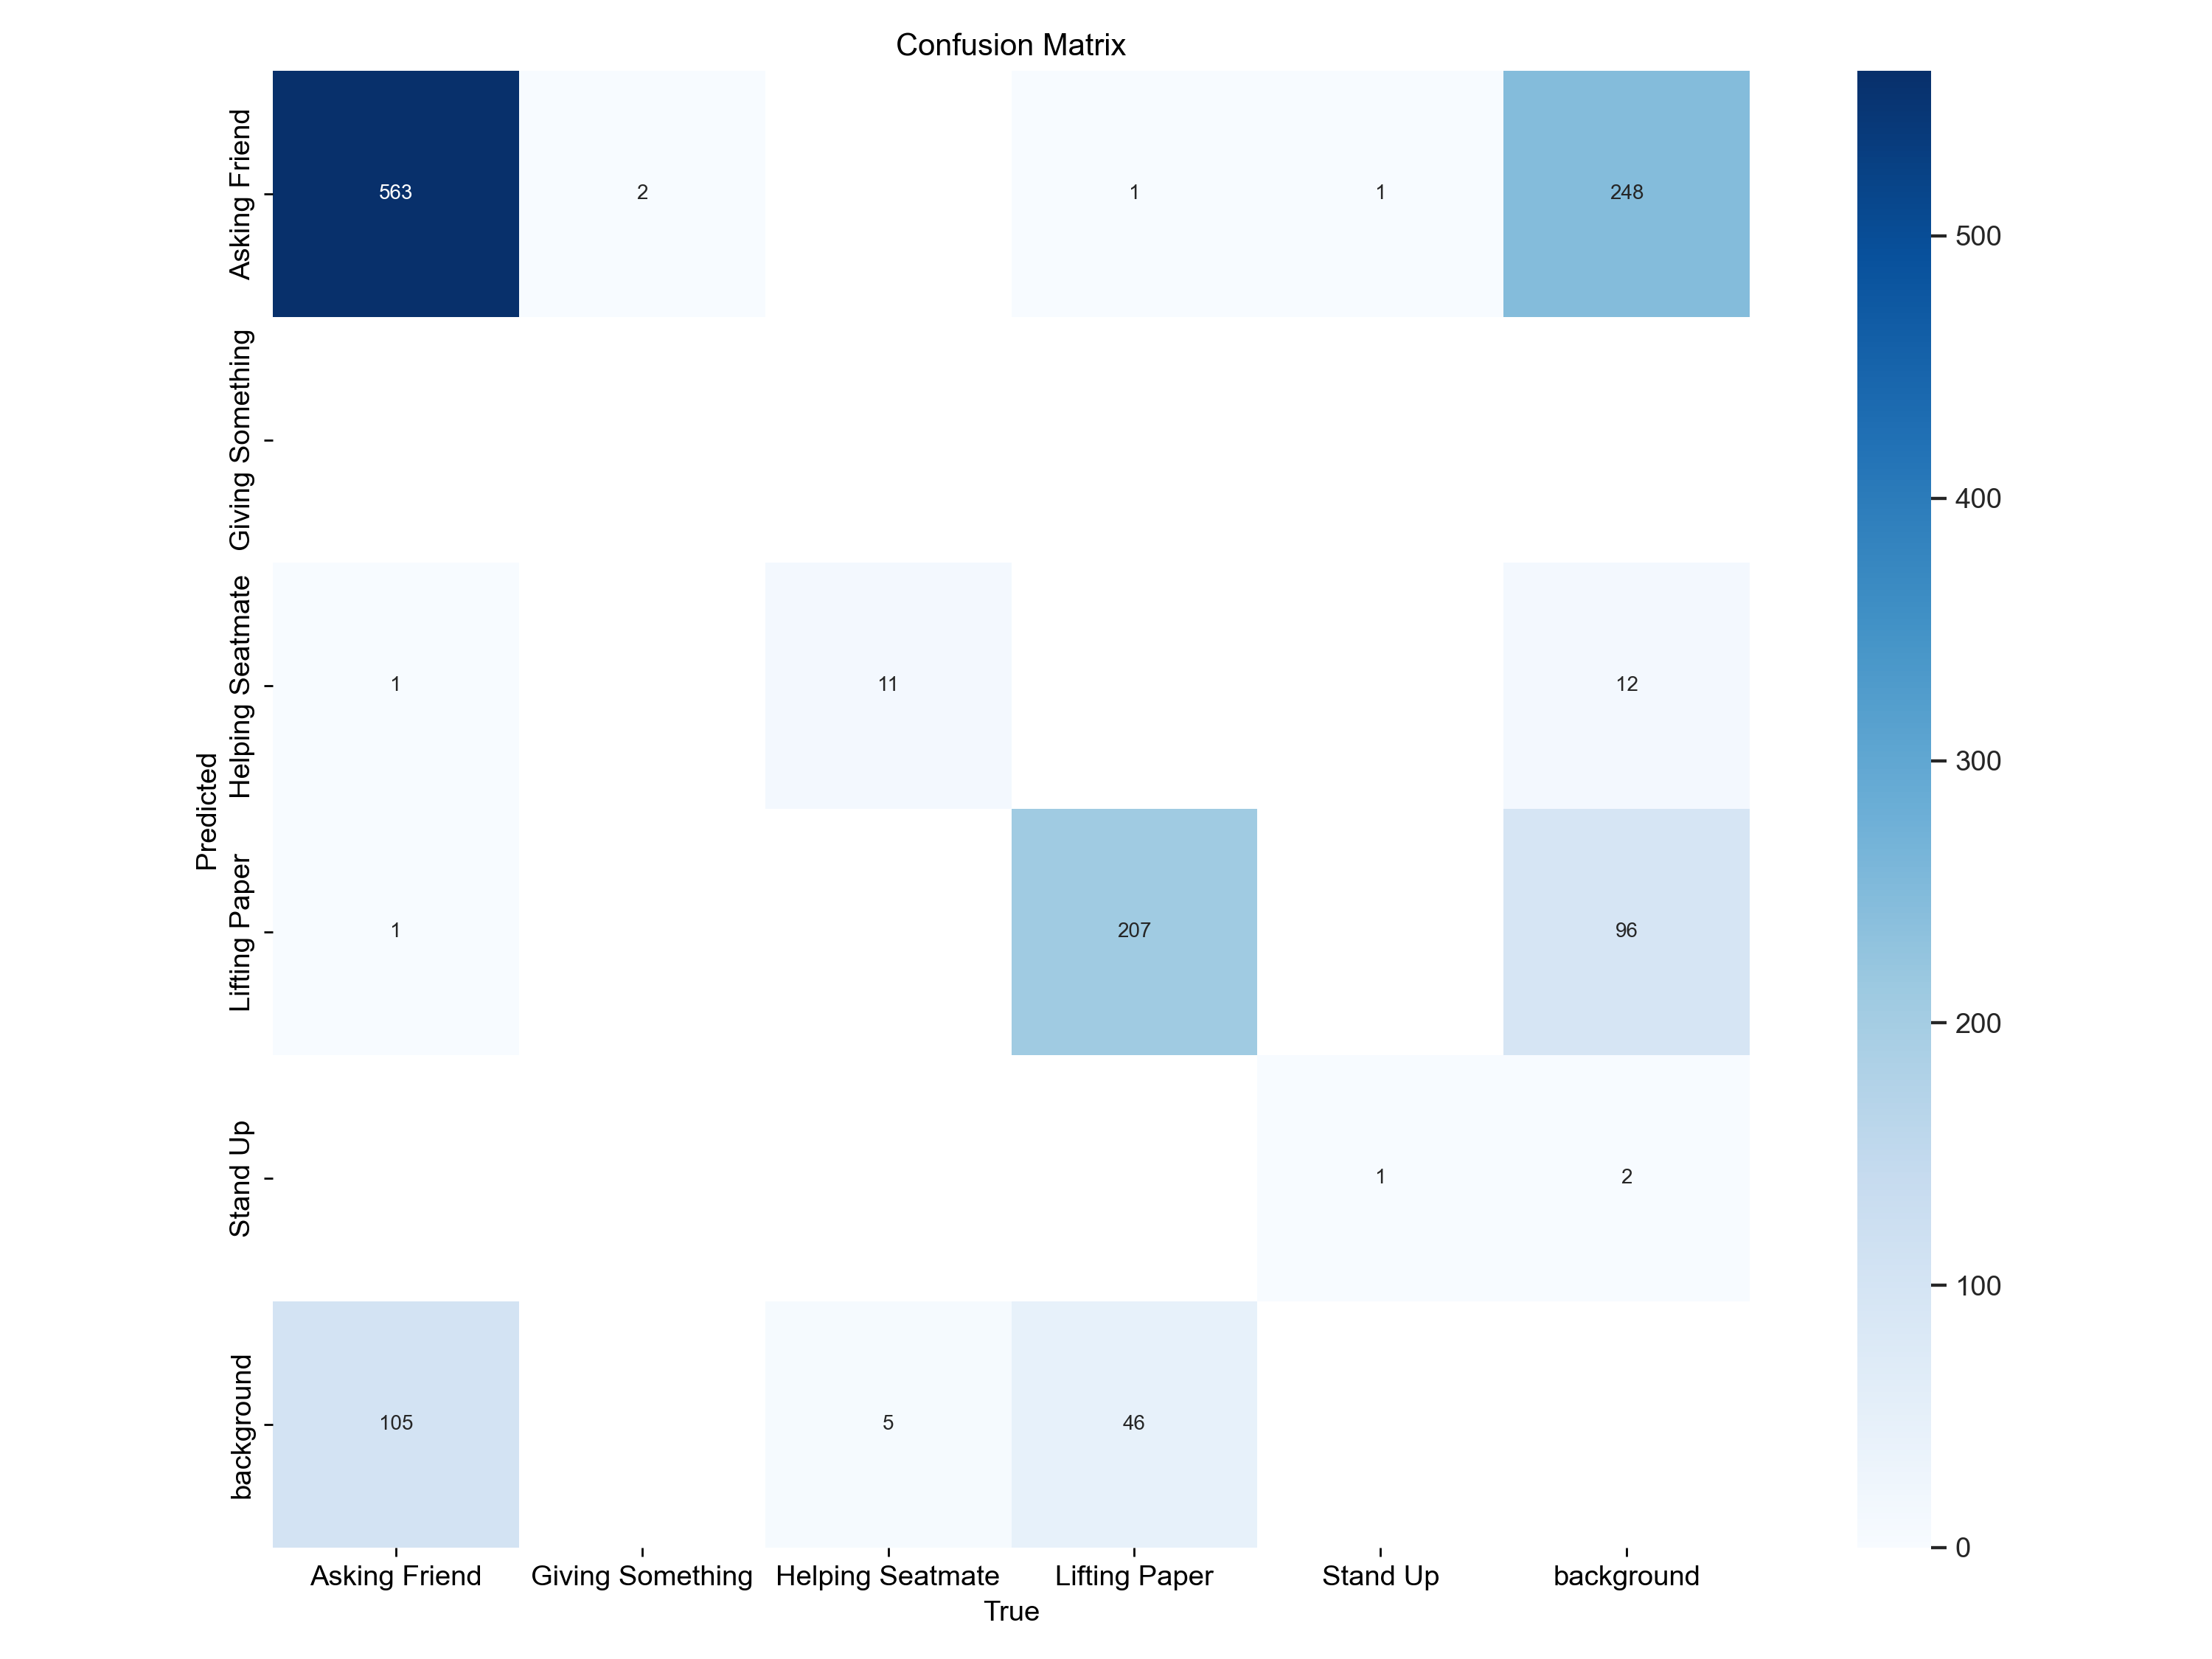

In [23]:
x = Image(filename='runs/detect/train/F1_curve.png')
y = Image(filename='runs/detect/train/PR_curve.png')
z = Image(filename='runs/detect/train/confusion_matrix.png')
display(x, y,z)

# Yolo V11

In [24]:
cd D:\projects\Feb26\exam cheating

D:\projects\Feb26\exam cheating


In [25]:
!mkdir v11

In [26]:
cd v11

D:\projects\Feb26\exam cheating\v11


In [27]:
import urllib.request
url = "https://github.com/ultralytics/assets/releases/download/v0.0.0/yolov8n.pt"
destination = "yolo11x.pt"
urllib.request.urlretrieve(url, destination)

('yolo11x.pt', <http.client.HTTPMessage at 0x1cb05c8e110>)

In [28]:
model = YOLO("YOLO11x.pt")  

results = model.train(
    data=Data_dir, 
    epochs=50, 
    imgsz=416, 
    batch=32)  

New https://pypi.org/project/ultralytics/8.4.14 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.6  Python-3.10.9 torch-2.5.0+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: task=detect, mode=train, model=YOLO11x.pt, data=D:/projects/Feb26/exam cheating/Dataset/data.yaml, epochs=50, time=None, patience=100, batch=32, imgsz=416, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, em

100%|██████████████████████████████████████████████████████████████████████████████| 5.35M/5.35M [00:00<00:00, 111MB/s]


AMP: checks passed 


train: Scanning D:\projects\Feb26\exam cheating\Dataset\train\labels.cache... 6312 images, 39 backgrounds, 0 corrupt: 1
val: Scanning D:\projects\Feb26\exam cheating\Dataset\valid\labels.cache... 259 images, 1 backgrounds, 0 corrupt: 100%|


Plotting labels to runs\detect\train\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 63 weight(decay=0.0), 70 weight(decay=0.0005), 69 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 416 train, 416 val
Using 8 dataloader workers
Logging results to runs\detect\train
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      50/50      1.92G     0.8677      0.588     0.9014         25        416: 100%|██████████| 198/198 [00:47<00:00,  
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:01<0

                   all        259        944      0.747      0.685      0.651      0.314



50 epochs completed in 0.742 hours.
Optimizer stripped from runs\detect\train\weights\last.pt, 5.6MB
Optimizer stripped from runs\detect\train\weights\best.pt, 5.6MB

Validating runs\detect\train\weights\best.pt...
Ultralytics 8.3.6  Python-3.10.9 torch-2.5.0+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
Model summary (fused): 186 layers, 2,685,343 parameters, 0 gradients, 6.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<0


                   all        259        944       0.57      0.709      0.644      0.366
         Asking Friend        238        670      0.532      0.912      0.821      0.544
      Giving Something          2          2          1          0          0          0
      Helping Seatmate         16         16      0.221      0.812      0.641      0.516
         Lifting Paper        191        254      0.635      0.821      0.763      0.345
              Stand Up          2          2      0.462          1      0.995      0.423
Speed: 0.5ms preprocess, 2.2ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to runs\detect\train


In [29]:
p_yolo11 = 0.570
r_yolo11 = 0.709
mAP_yolo11 = 0.644

storeResults('Yolo v11',p_yolo11,r_yolo11,mAP_yolo11)

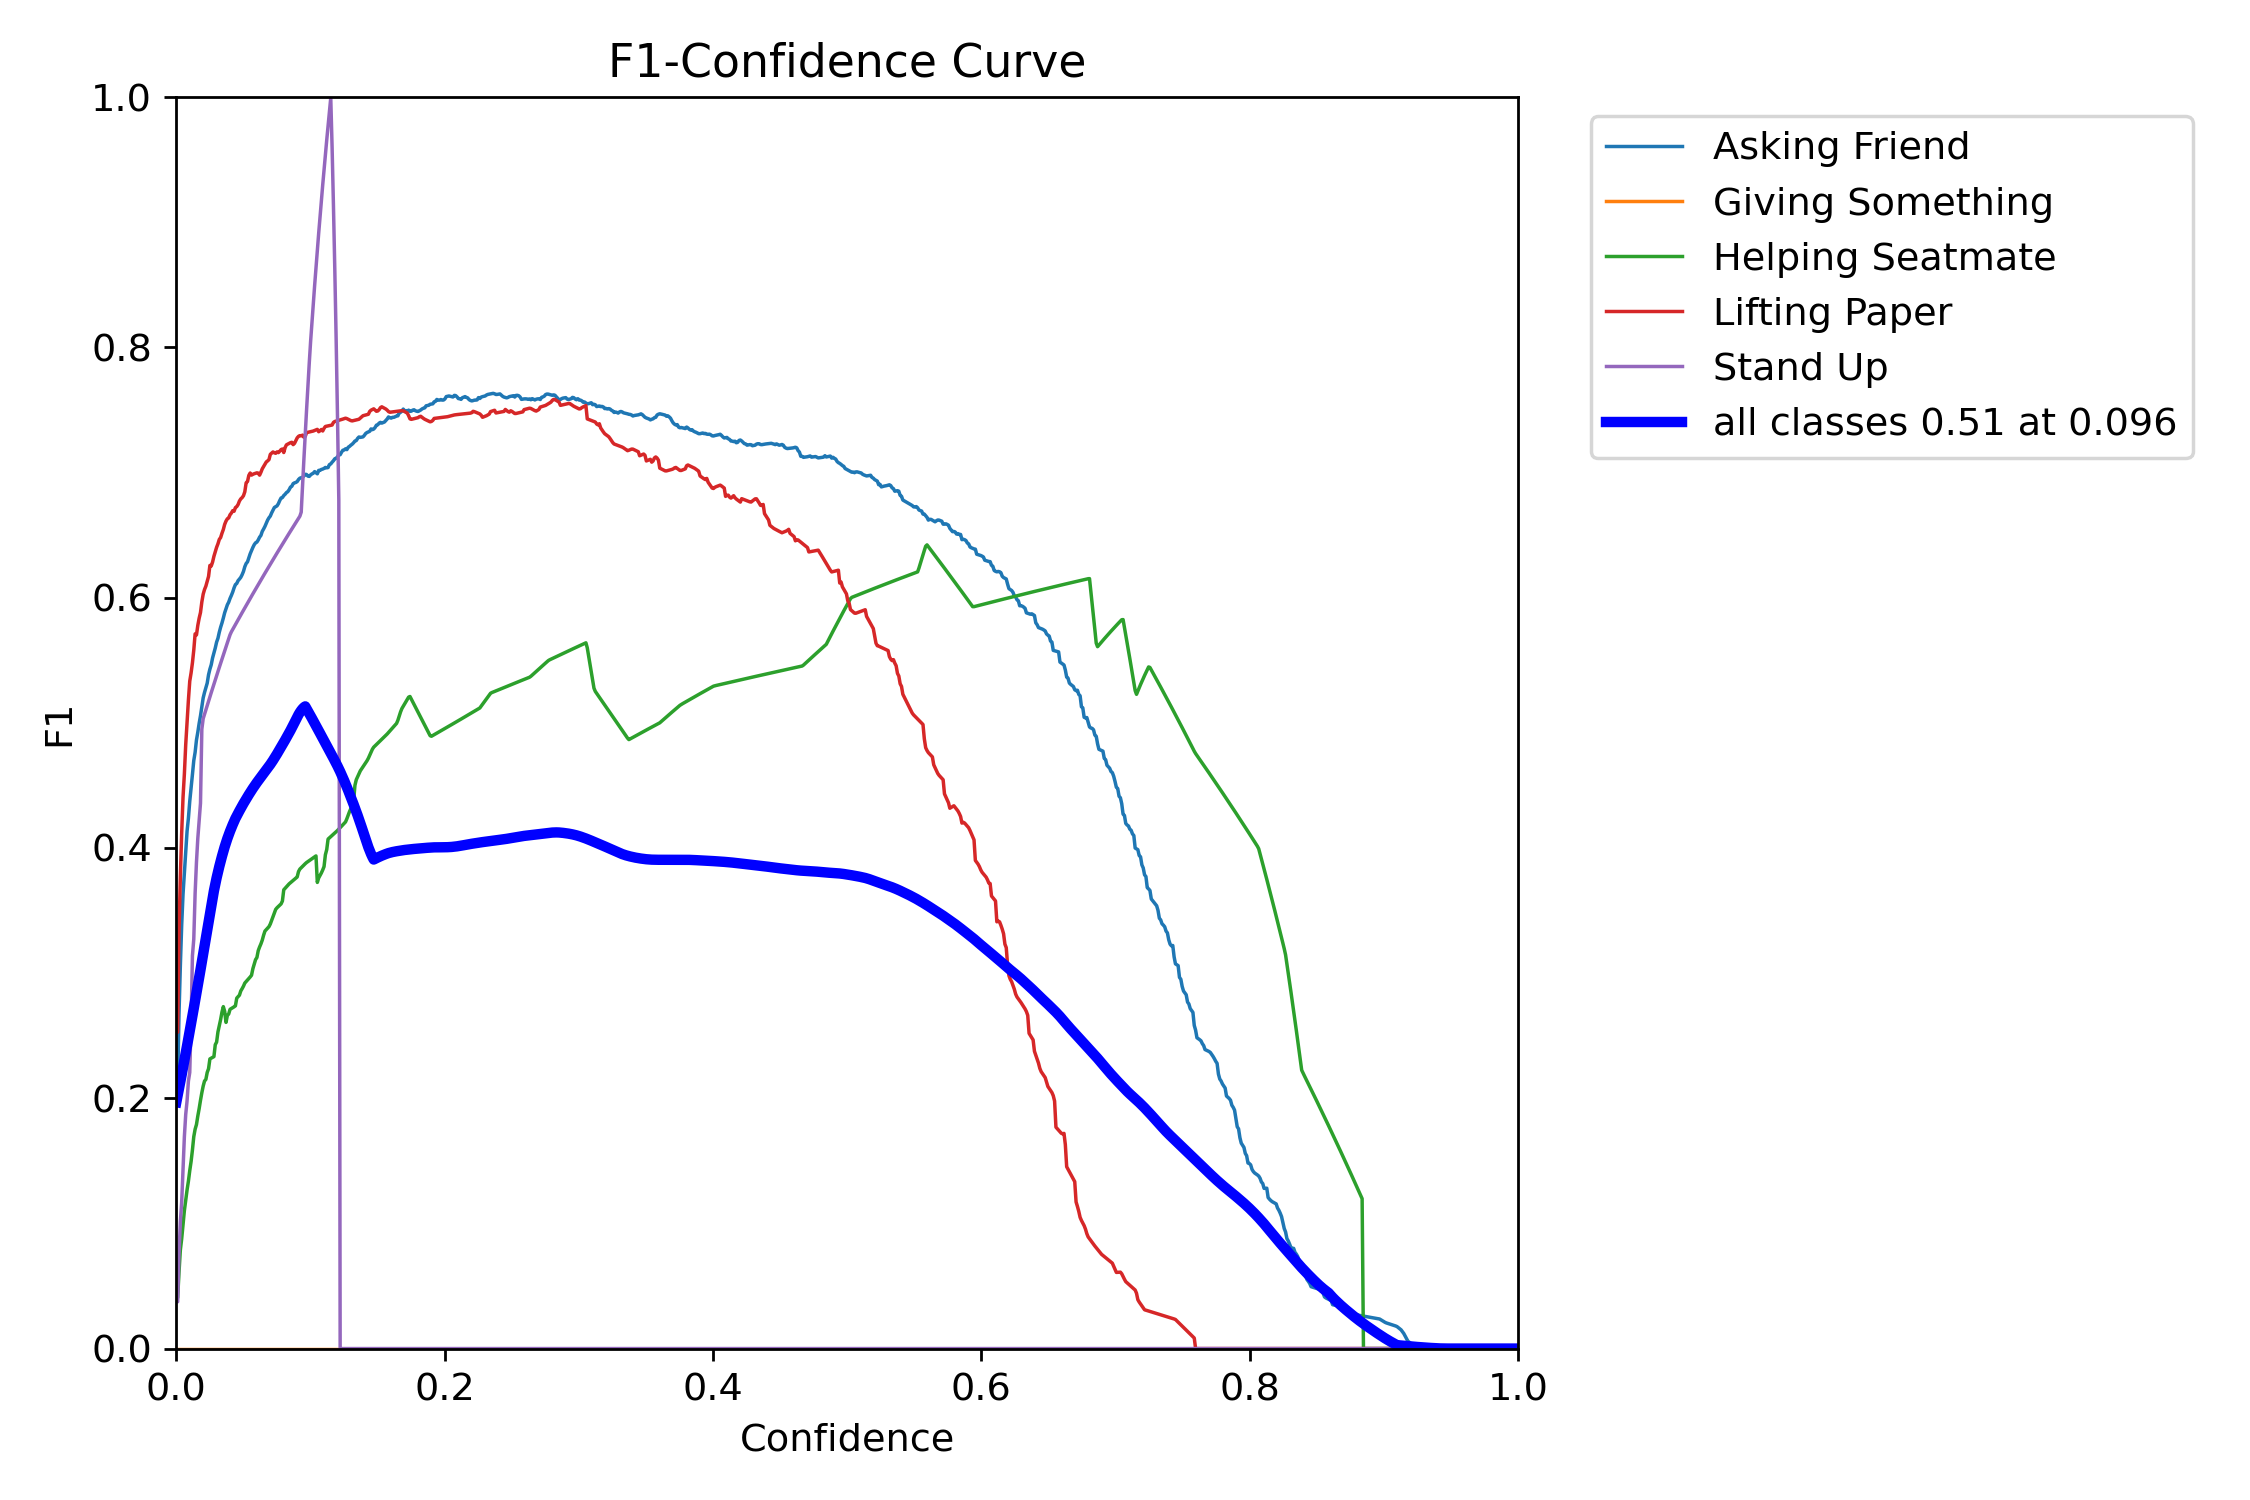

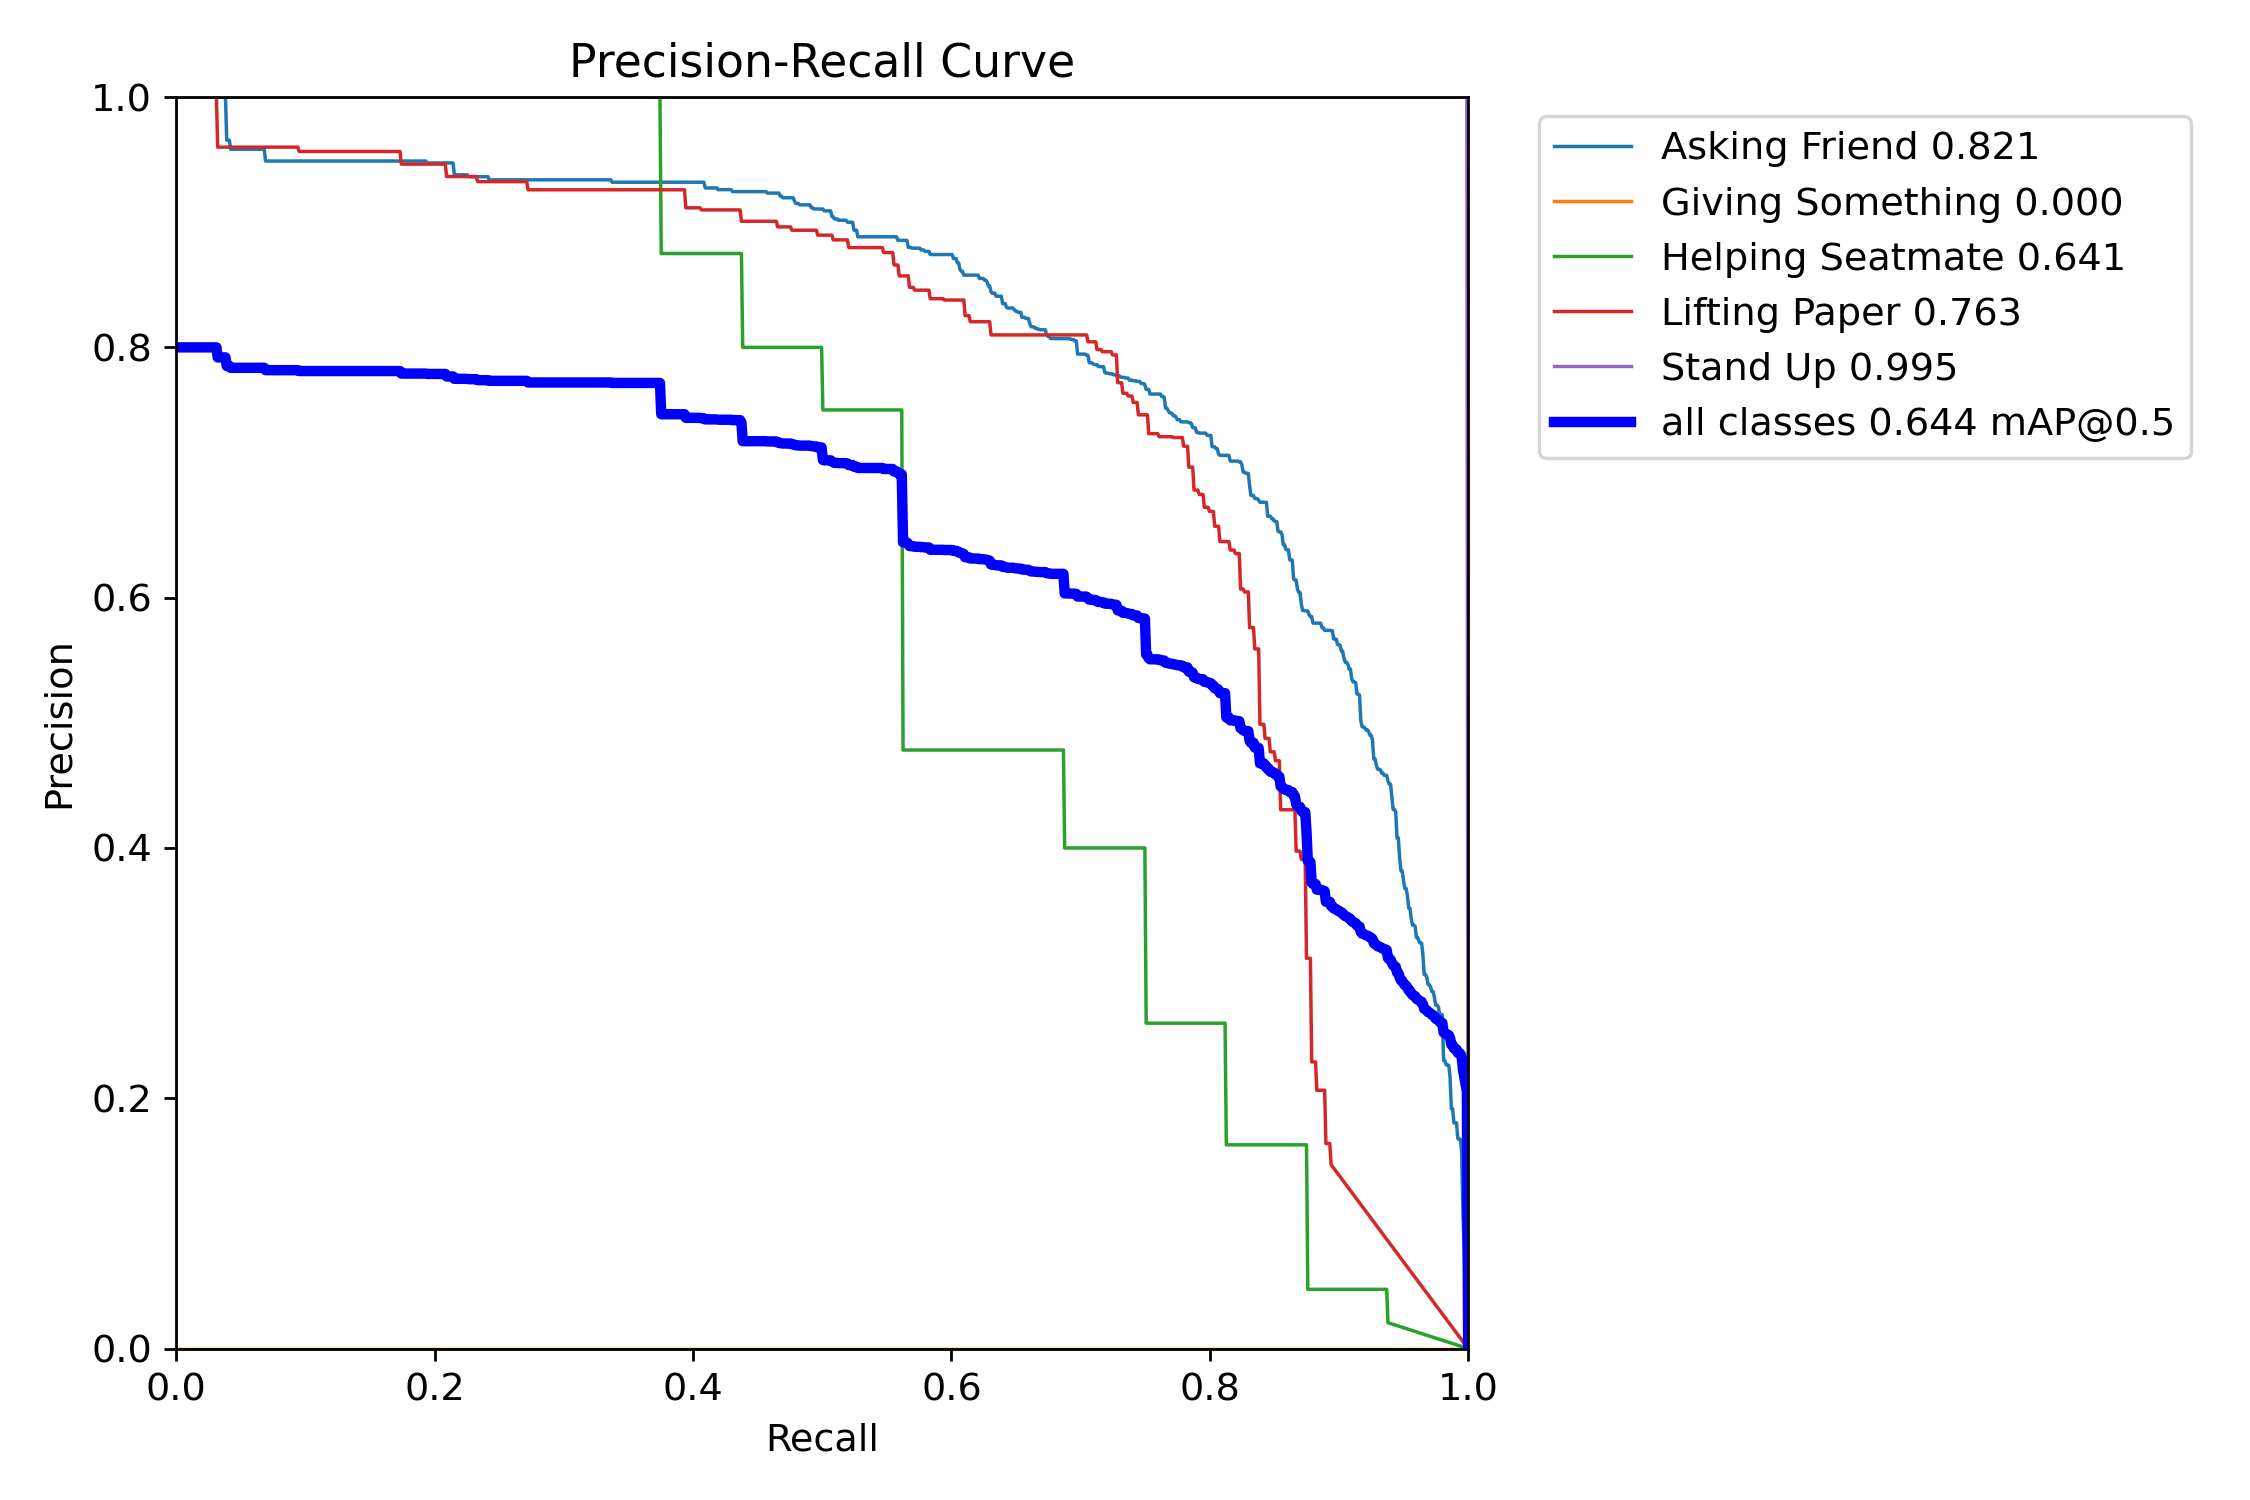

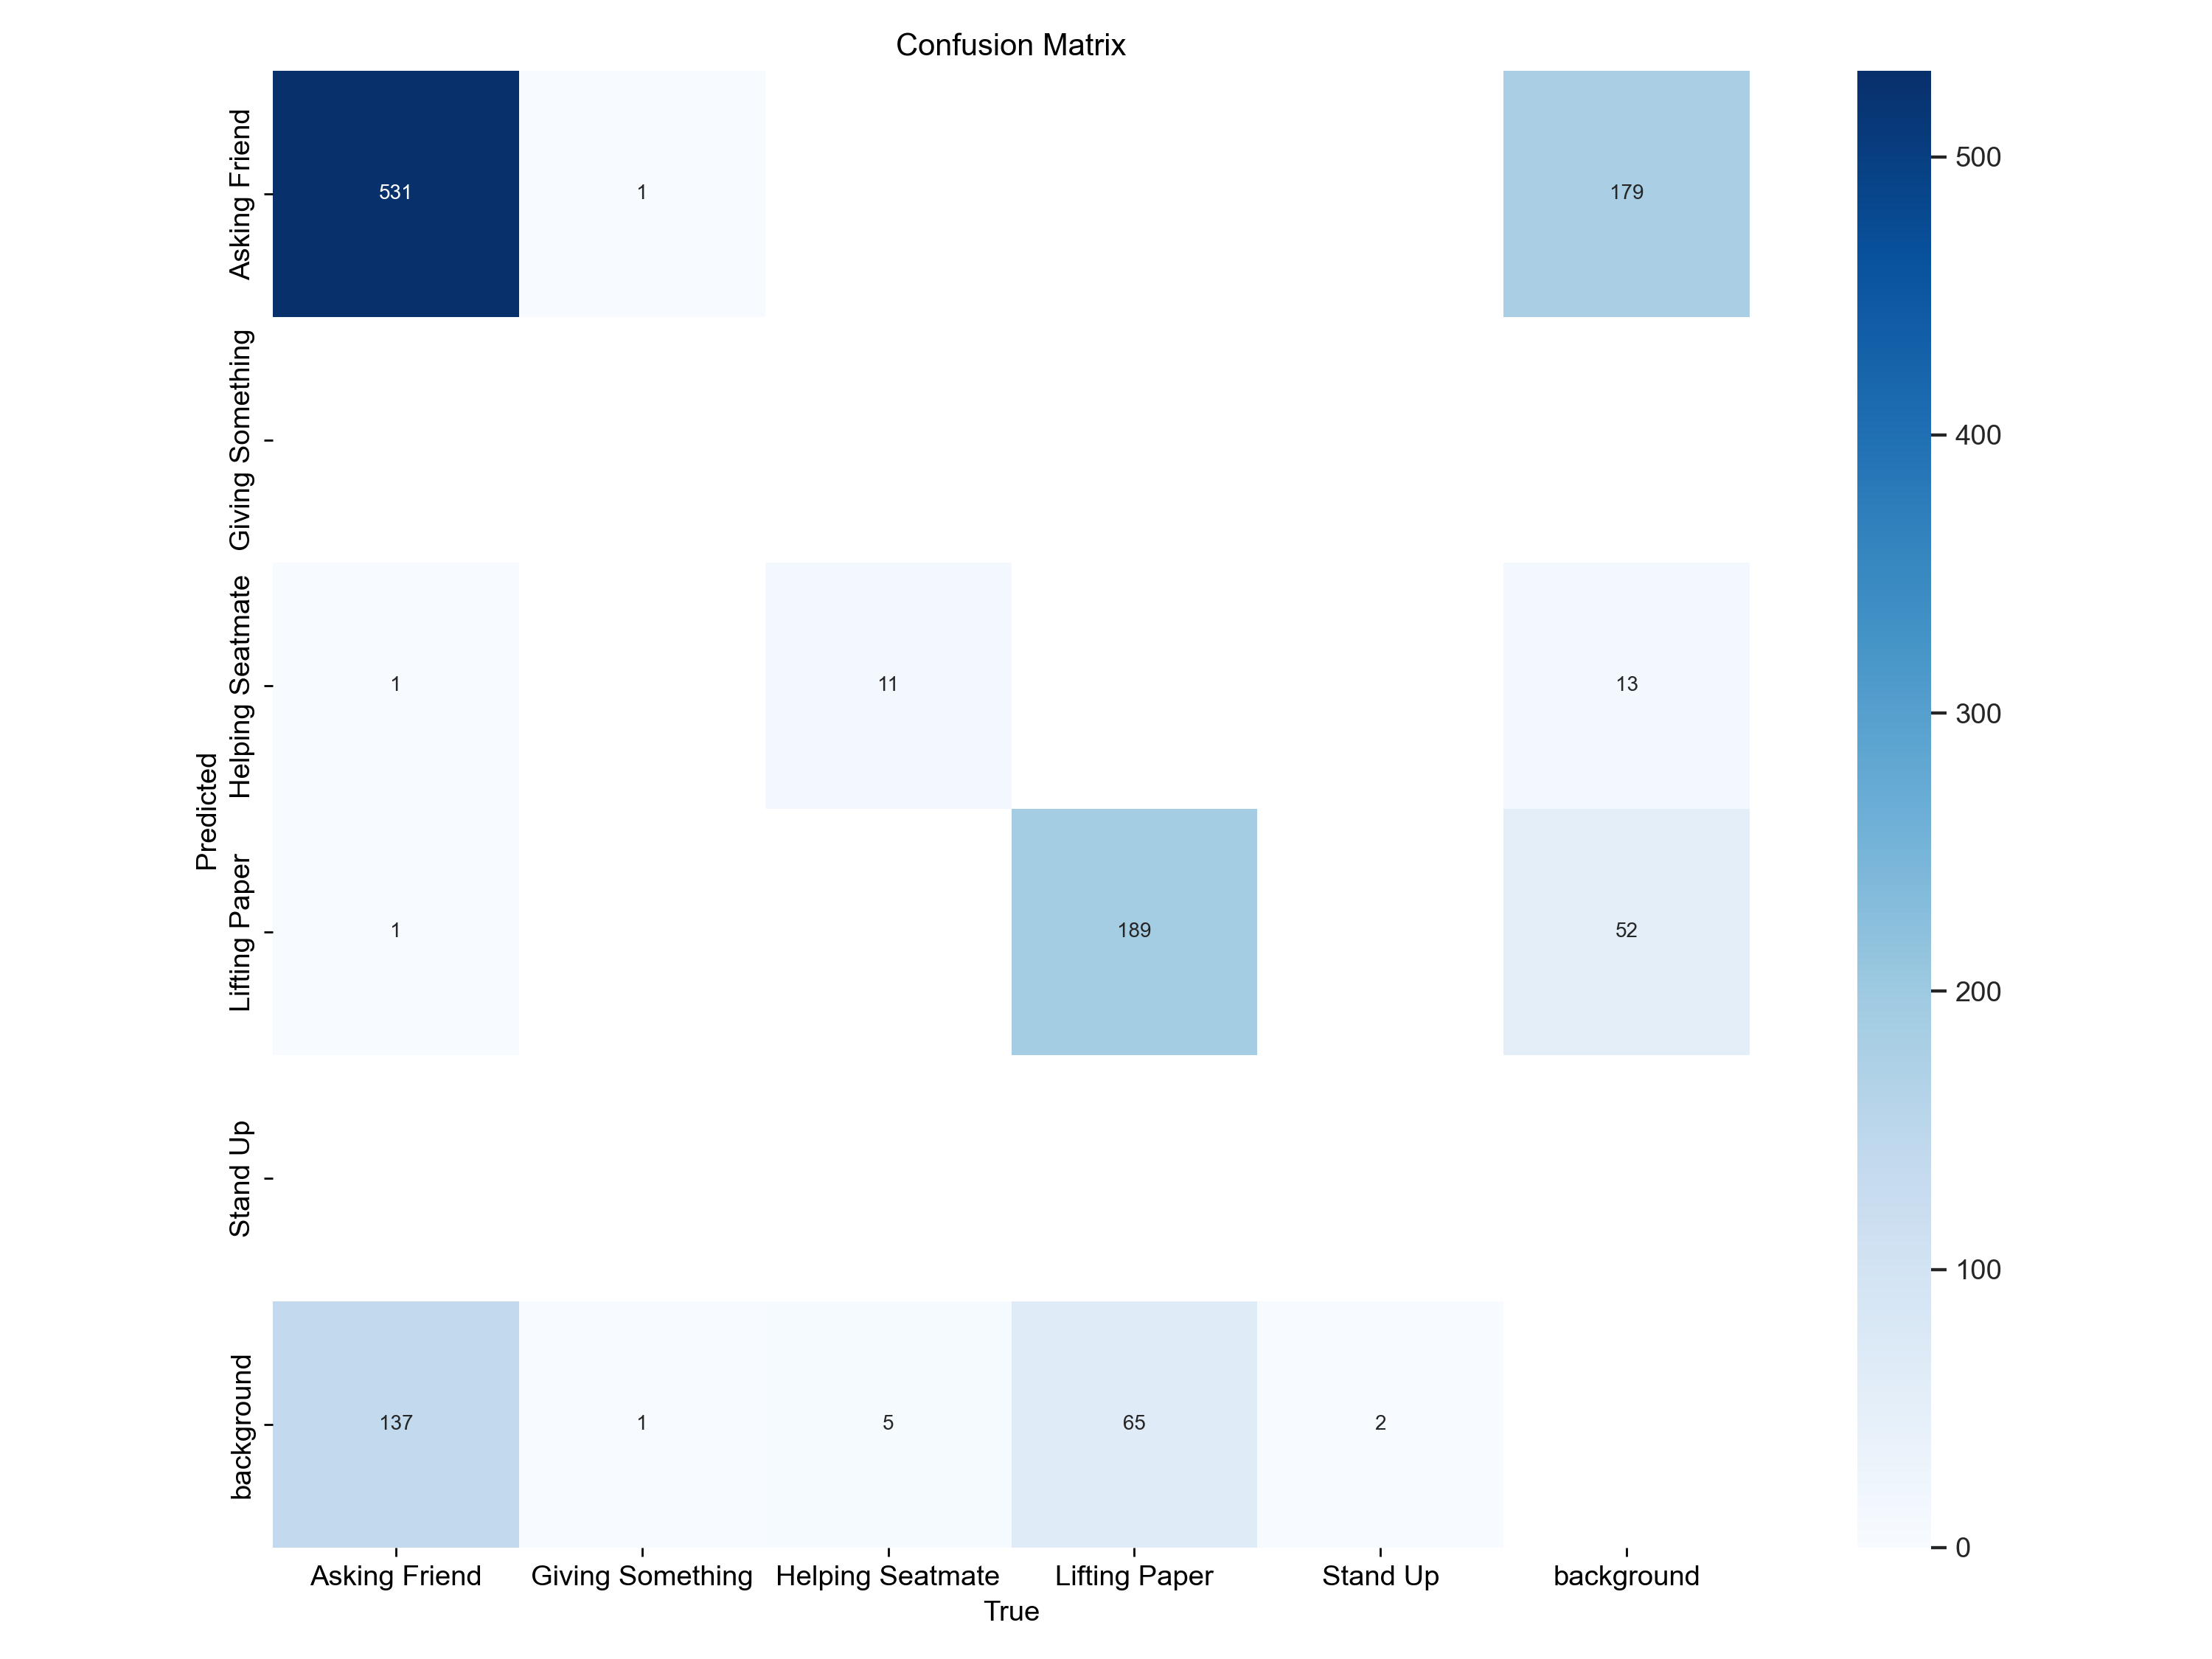

In [30]:
x = Image(filename='runs/detect/train/F1_curve.png')
y = Image(filename='runs/detect/train/PR_curve.png')
z = Image(filename='runs/detect/train/confusion_matrix.png')
display(x, y,z)

# Comparison

In [33]:
import pandas as pd
result = pd.DataFrame({ 'ML Model' : ML_Model,
                       'Precision': precision,
                       'Recall'   : recall,
                       'mAP' : mAP,
                      })

In [34]:
result

,ML Model,Precision,Recall,mAP
0,Yolo V8,0.570,0.709,0.644
1,Yolo v5,0.848,0.612,0.663
2,Yolo v9,0.828,0.598,0.659
3,Yolo v11,0.570,0.709,0.644


# Graph

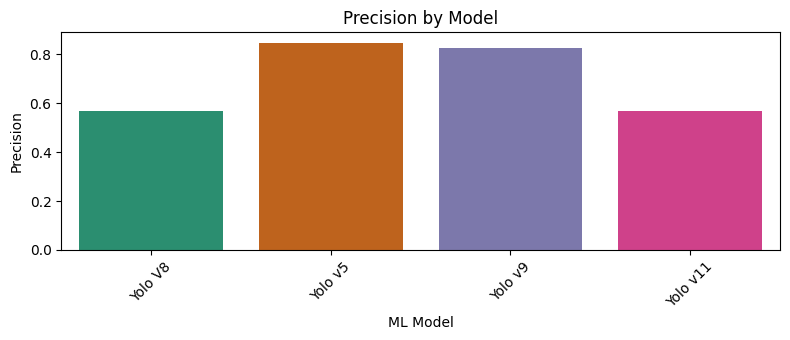

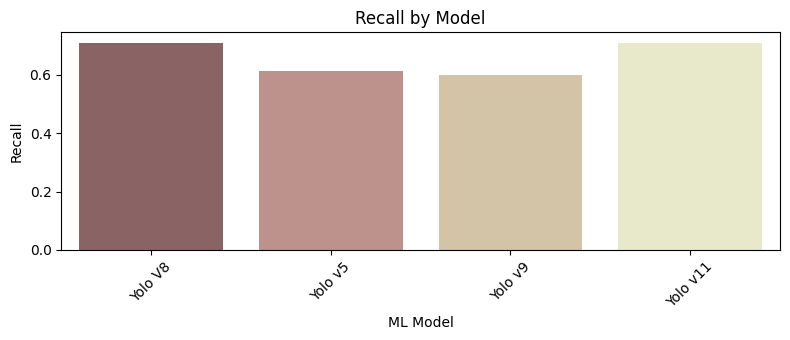

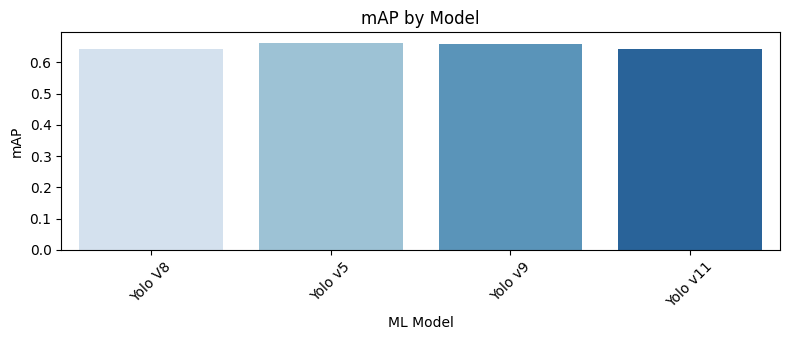

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define a different palette for each metric
palettes = {
    'Precision': 'Dark2',
    'Recall': 'pink',
    'mAP': 'Blues'
}

for metric in ['Precision', 'Recall', 'mAP']:
    plt.figure(figsize=(8, 3.5))
    sns.barplot(data=result, x='ML Model', y=metric, palette=palettes[metric])
    plt.title(f'{metric} by Model')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()